In [2]:
import pandas as pd
import numpy as np
import importlib
from tqdm import tqdm

import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


import plotly.express as px
from matplotlib.animation import FuncAnimation

import utility_functions as uf

In [3]:
mode = "individual"

df_cs_yearly = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs(mode, level=2)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

n_years = 5

df_cs_yearly = (
    df_cs_yearly
    .sort_index()
    .groupby(level=0)
    .rolling(n_years).sum()
    .reset_index(level=0, drop=True)
)
df_prob_yearly = df_cs_yearly.div(df_cs_yearly.sum(axis=1), axis=0)

df_dist_yearly = pd.read_csv(uf.PATH+f"df_dist_w1_rolling_yearly_{mode}.csv", index_col=[0, 1])

In [4]:
import geopandas as gpd
import matplotlib.patches as mpatches

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world_url = gpd.read_file(url)

In [5]:
df_map_analysis = pd.read_csv(uf.PATH+"df_map_analysis_01.csv").dropna(subset="cluster")

In [6]:
# df_map_analysis.to_csv(uf.PATH+"df_map_analysis_005.csv", index=False)

In [7]:
df_gdp_yearly = pd.read_csv(uf.PATH+"gdp-per-capita-worldbank.csv", index_col=[1, 2])

In [8]:
df_map_analysis.dropna(subset="cluster")

,year,country,cluster
0,1975,AR,8.0
1,1975,AT,0.0
2,1975,AU,7.0
3,1975,BE,5.0
4,1975,BG,4.0
...,...,...,...
3853,2023,VN,12.0
3854,2023,YE,5.0
3855,2023,ZA,12.0
3856,2023,ZM,10.0


In [254]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [303]:
importlib.reload(uf)

<module 'utility_functions' from '/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py'>

In [304]:
df1 = df_prob_yearly.xs(2023, level=1).loc["US"].to_frame("prob1").T
df2 = df_prob_yearly.xs(2023, level=1).loc["CN"].to_frame("prob2").T

In [306]:
uf.get_w1_distances_matrix(df1, df2)

0.222
[1.    0.1   0.1   0.1   0.1   0.01  0.01  0.01  0.01  0.01  0.01  0.01
 0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01
 0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.00

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1375: RuntimeWarning:

invalid value encountered in matmul



idx2,prob2
idx1,
prob1,0.27009


In [ ]:
df_tree = uf.df_topics[["domain_id", "field_id", "subfield_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])
sf_list = df_tree.subfield_id.astype(str).to_list()
df1 = df_prob_yearly.xs(2023, level=1).loc["US"].to_frame("prob1").T[sf_list]
df2 = df_prob_yearly.xs(2023, level=1).loc["CN"].to_frame("prob2").T[sf_list]

wass_array, n = uf.get_wass_array(df_tree)
uf.get_w1_distance_matrix(df1.fillna(0).values[0], df2.fillna(0).values[0], wass_array[:, n:])

[1.    0.1   0.1   0.1   0.1   0.01  0.01  0.01  0.01  0.01  0.01  0.01
 0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01
 0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.00

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1246: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1260: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1260: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1260: RuntimeWarning:

invalid value encountered in matmul



np.float64(0.05996001547537706)

In [311]:
df_tree = uf.df_topics[["domain_id", "field_id", "subfield_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])
sf_list = df_tree.subfield_id.astype(str).to_list()
df1 = df_prob_yearly.xs(2023, level=1).loc["US"].to_frame("prob1").T[sf_list]
df2 = df_prob_yearly.xs(2023, level=1).loc["CN"].to_frame("prob2").T[sf_list]


uf.get_w1_distances(uf.get_subfield_tree(uf.df_topics), pd.concat([df1, df2]))

,prob1,prob2
prob1,0.00000,0.27009
prob2,0.27009,0.00000


# Utilities

In [9]:
# df_baricenter_yearly_list = []

# year_list = df_map_analysis.year.drop_duplicates().sort_values().to_list()

# for year_loop in year_list:
#     country_list = df_map_analysis.query("year == @year_loop").country.to_list()
#     df_prob = df_prob_yearly.xs(year_loop, level=1).loc[country_list]
#     # print(df_prob["3002"])
#     df_baricenter_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
    
# df_baricenter_global_yearly = pd.concat(df_baricenter_yearly_list, axis=1).T

In [10]:
year_list = df_map_analysis.year.drop_duplicates().sort_values().to_list()

In [13]:
# df_baricenter_global_yearly.to_csv(uf.PATH+"df_barycenter_global_yearly_collab.csv")
df_baricenter_global_yearly = pd.read_csv(uf.PATH+"df_barycenter_global_yearly.csv", index_col=0)

In [14]:
cluster_list = df_map_analysis.cluster.drop_duplicates().sort_values().to_list()
subfield_tree = uf.get_subfield_tree(uf.df_topics)

In [630]:
# profile_yearly_list = []
# for cluster_loop in cluster_list:
#     cluster_year_list = df_map_analysis.query("cluster == @cluster_loop").year.drop_duplicates().sort_values().to_list()
#     cluster_profile_yearly_list = []
#     for year_loop in cluster_year_list:
#         cluster_country_list = df_map_analysis.query("cluster == @cluster_loop and year == @year_loop").country.drop_duplicates().sort_values().to_list()
#         if cluster_country_list == []:
#             print(year_loop, cluster_loop)
#             continue
#         # print(cluster_country_list)
#         df_prob = df_prob_yearly.xs(year_loop, level=1).loc[cluster_country_list]
#         cluster_profile_yearly_list.append(uf.get_w1_barycenter(df_prob).T.rename(columns={0: year_loop}))
#     # print(cluster_profile_yearly_list)
#     if cluster_profile_yearly_list == []:
#         print(year_loop, cluster_loop)
#         continue
#     profile_yearly_list.append(pd.concat(cluster_profile_yearly_list, axis=1).T.assign(cluster=cluster_loop))
# df_profile_yearly = pd.concat(profile_yearly_list).reset_index(names="year").set_index(["cluster", "year"])

In [15]:
# df_profile_yearly.to_csv(uf.PATH+"df_profile_by_cluster_collab.csv")
df_profile_yearly = pd.read_csv(uf.PATH+"df_profile_by_cluster_01.csv", index_col=[0, 1])

In [16]:
pivot = df_map_analysis.pivot(index="country", columns="year", values="cluster")
pivot

clusters = pivot.values

# Broadcasting comparison
same_cluster = clusters[:, None, :] == clusters[None, :, :]

# Count matches across years
co_membership = same_cluster.sum(axis=2)

# Convert back to dataframe
df_neighbours_counts = pd.DataFrame(
    co_membership,
    index=pivot.index,
    columns=pivot.index
)

# df_n_years = pd.DataFrame(
#     co_membership,
#     index=pivot.index,
#     columns=pivot.index
# )
# df_dist_clusters_yearly = 1 - df_n_years.div(np.diagonal(df_n_years.values))

# # df_dist_clusters_yearly.to_csv(uf.PATH+f"df_dist_countries_{param_value}_medoid_short_w1_{mode}.csv", index=True)

In [17]:
df_stats_cluster = uf.get_cluster_stats(df_map_analysis, df_cs_yearly.reset_index(), df_dist_yearly.reset_index())
all_clusters = df_map_analysis.cluster.drop_duplicates().sort_values()

n_countries_global = df_map_analysis.groupby(["year"], as_index=True).country.nunique()
std = df_baricenter_global_yearly.std()


In [18]:
# uf.plotly_heatmap(df_baricenter_global_yearly,
#                   x_labels=df_baricenter_global_yearly.columns,
#                   y_labels=df_baricenter_global_yearly.index,
#                   colorscale="non",
#                   z_min=0, z_max=0.02,
#                   line_height=10,
#                   x_type="subfield")

In [19]:
# RED = "#4E0000"
# BLUE = "#13273F"
# YELLOW = "#CB8E16"


BLUE = "#8C9EFF"
# GREEN = "#D6F74C"
GREEN = "#285B23"
ORANGE = "#F06038"
BRONZE = "#FCD9BE"
PURPLE = "#6f2dbd"
ROSE = "#d1495b"

# BLUE = "#192741"
# GREEN = "#404322"
# ORANGE = "#AD4A18"
# BRONZE = "#CE8A39"

BLUE_DARK = "#193254"
GREEN_DARK = "#35521C"
ORANGE_DARK = "#943D14"
BRONZE_DARK = "#E39F3D"

BLUE_LIGHT = "#0D1AA8"
GREEN_LIGHT = "#404322"
ORANGE_LIGHT = "#AD4A18"
BRONZE_LIGHT = "#CE8A39"

colors_domain = {
    "Physical Sciences": ORANGE,
    "Social Sciences": PURPLE,
    "Health Sciences": ROSE,
    "Life Sciences": BLUE
    # "Physical Sciences": [ORANGE_LIGHT, ORANGE_DARK],
    # "Social Sciences": [BLUE_LIGHT, BLUE_DARK],
    # "Health Sciences": [GREEN_LIGHT, GREEN_DARK],
    # "Life Sciences": [BRONZE_LIGHT, BRONZE_DARK]
}

In [20]:
def white_to_color(color, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"white_to_{color}",
        ["white", color],
        N=n
    )

def from_color_list(color_list, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"from_list",
        color_list,
        N=n
    )

def truncate_cmap(cmap, minval=0.3, maxval=1.0, n=256):
    return mcolors.LinearSegmentedColormap.from_list(
        f"trunc_{cmap.name}",
        cmap(np.linspace(minval, maxval, n))
    )


In [21]:
def get_spec(cluster, df_map_analysis, std, df_baricenter_global_yearly):
    years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
    n_countries_global = df_map_analysis.groupby(["year"], as_index=True).country.nunique()

    n_countries_cluster = df_map_analysis.query("cluster == @cluster").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
    mult = 1 / np.sqrt(
        pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std.index)
        .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0)).dropna(how="all")

    return (
        df_profile_yearly
        .xs(cluster, level=0)
        .sub(df_baricenter_global_yearly.loc[years_list])
        .mul(mult.loc[years_list])
    )
    # return (
    #     df_profile_yearly
    #     .xs(cluster, level=0)
    #     .sub(df_baricenter_global_yearly.loc[years_list])
    # )

In [22]:
def get_prob_fields(df_prob):
    return (
        df_prob
        .T
        .merge(uf.df_topics[["subfield_id", "field_name", "domain_id"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
            left_index=True, right_on="subfield_str", how="left")
        .drop(columns=["subfield_str", "subfield_id"])
        .groupby(["domain_id", "field_name"], as_index=False)
        .sum()
        .sort_values(["domain_id", "field_name"])
        .drop(columns="domain_id")
        .set_index("field_name")
        .T
    )

In [23]:
def get_spec_fields(cluster, df_map_analysis, std, df_baricenter_global_yearly):
    years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
    n_countries_global = df_map_analysis.groupby(["year"], as_index=True).country.nunique()

    df_profile_fields = get_prob_fields(df_profile_yearly.xs(cluster, level=0))
    df_global_profile_fields = get_prob_fields(df_baricenter_global_yearly)
    std_fields = df_global_profile_fields.std()

    n_countries_cluster = df_map_analysis.query("cluster == @cluster").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
    mult = 1 / np.sqrt(
        pd.DataFrame((std_fields ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std_fields.index)
        .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0)).dropna(how="all")

    return (
        df_profile_fields
        .sub(df_global_profile_fields.loc[years_list])
        .mul(mult.loc[years_list])
    )
    # return (
    #     df_profile_fields
    #     .sub(df_global_profile_fields.loc[years_list])
    # )

In [24]:
df_profile_spec_yearly_list = []
for cluster_loop in all_clusters:
    df_profile_spec_yearly_list.append(get_spec(cluster_loop, df_map_analysis, std, df_baricenter_global_yearly).reset_index().assign(cluster=cluster_loop))
df_profile_spec_yearly = pd.concat(df_profile_spec_yearly_list).set_index(["cluster", "year"])

In [25]:
df_profile_spec_fields_yearly_list = []
for cluster_loop in all_clusters:
    # print(cluster_loop)
    df_profile_spec_fields_yearly_list.append(get_spec_fields(cluster_loop, df_map_analysis, std, df_baricenter_global_yearly).reset_index(names="year").assign(cluster=cluster_loop))
df_profile_spec_fields_yearly = pd.concat(df_profile_spec_fields_yearly_list).set_index(["cluster", "year"])

In [26]:
sf = "1110"
n_all = df_map_analysis.query("year == 2023").groupby("cluster", as_index=False).country.nunique().country.sum()

std = (
    df_prob_yearly.xs(2023, level=1)
    .merge(df_map_analysis.query("year == 2023")[["country", "cluster"]], left_index=True, right_on="country", how="left")
    [sf]
    .std()
)

div_test = (
    (n_all - df_map_analysis.query("year == 2023").groupby("cluster").country.nunique().to_frame("n_countries"))
    / (n_all - 1)
    * std ** 2
    / df_map_analysis.query("year == 2023").groupby("cluster").country.nunique().to_frame("n_countries")
)

res = ((
    df_prob_yearly.xs(2023, level=1)
    .merge(df_map_analysis.query("year == 2023")[["country", "cluster"]], left_index=True, right_on="country", how="left")
    .groupby("cluster", as_index=False)
    [sf]
    .mean()
    .set_index("cluster")
) - (
    df_prob_yearly.xs(2023, level=1)
    .merge(df_map_analysis.query("year == 2023")[["country", "cluster"]], left_index=True, right_on="country", how="left")
    [sf]
    .mean()
)) / np.sqrt(div_test.values)
# res
res / res.abs().sum()

,1110
cluster,
0.0,NaN
5.0,0.159252
10.0,-0.356895
12.0,-0.483853


In [27]:
df_profile_spec_yearly.xs(2023, level=1)[[sf]]

,1110
cluster,
0.0,NaN
5.0,-22.244696
10.0,-5.476417
12.0,-22.259494


In [28]:
df_profile_norm_spec_fields_yearly_list = []
for year_loop in year_list:    
    df_profile_norm_spec_fields_yearly_list.append(
        df_profile_spec_fields_yearly.xs(year_loop, level=1)
        .div(df_profile_spec_fields_yearly.xs(year_loop, level=1).abs().sum())
        .assign(year=year_loop)
    )

df_profile_norm_spec_fields_yearly = pd.concat(df_profile_norm_spec_fields_yearly_list).reset_index().set_index(["cluster", "year"])

In [29]:
df_dist_country_cluster_raw_list = []
for year_loop in df_map_analysis.year.drop_duplicates().sort_values():
    df1 = df_prob_yearly.xs(year_loop, level=1)
    df2 = df_profile_yearly.xs(year_loop, level=1)

    df_dist_country_cluster_raw_list.append(uf.get_w1_distances_matrix(df1, df2)
                                            .reset_index(names="country")
                                            .melt(id_vars="country", var_name="cluster")
                                            .assign(year=year_loop)
                                            )
df_dist_country_cluster_raw = pd.concat(df_dist_country_cluster_raw_list)

df_dist_country_cluster = (
    df_dist_country_cluster_raw
    .assign(cluster_int=lambda df: df.cluster.astype(float))
    .drop(columns="cluster")
    .rename(columns={"cluster_int": "cluster"})
    .merge(df_map_analysis, on=["country", "year"], how="right", suffixes=["_dist", "_map"])
    .assign(in_cluster=lambda df: (df.cluster_dist == df.cluster_map).astype(int))
    # .groupby("cluster").value.mean()
)

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning: divide by zero encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning: overflow encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning: invalid value encountered in matmul
  q12 = np.matmul(q11, adj_leaves)
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning: divide by zero encountered in matmul
  np.sum(np.abs(wass_array_short @ df_diff.fillna(0).values.T), axis=0),
/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning: overflow encountered in matmul
  np.sum(np.abs(wass_array_short @ df_diff.fillna(0).values.T), a

# Overview

In [30]:
uf.plotly_heatmap(df_baricenter_global_yearly, df_baricenter_global_yearly.columns, df_baricenter_global_yearly.index,
                  colorscale="non", z_min=0, z_max=0.05, line_height=10, x_type="subfield", title="Global barycenter profile")

In [31]:
cluster_spec_list = []
for cluster_loop in all_clusters:
    if cluster_loop == 0:
        continue
    years_list = df_map_analysis.query("cluster == @cluster_loop").year.drop_duplicates().sort_values().to_list()

    # n_countries_cluster = df_map_analysis.query("cluster == @cluster_loop").drop(columns="cluster").groupby(["year"], as_index=True).nunique().country
    # mult = 1 / np.sqrt(
    #     pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.to_frame("a").values, index=n_countries_cluster.index, columns=std.index)
    #     .mul((n_countries_global - n_countries_cluster) / (n_countries_global - 1), axis=0)).dropna(how="all")

    # display(df_profile_norm_spec_fields_yearly.xs(cluster_loop).T)
    tmp_dict = (
        df_profile_norm_spec_fields_yearly.xs(cluster_loop).T
        .mean(axis=1)
        .to_frame("median_spec")
        .merge(uf.df_topics[["field_name", "domain_name"]].drop_duplicates(),
            left_index=True, right_on="field_name")
        # .groupby(["field_name", "domain_name"], as_index=False)
        .groupby(["domain_name"], as_index=False)
        .median_spec
        .sum()
        .sort_values("median_spec")
        # .assign(median_spec_norm = lambda df: df.median_spec / df.median_spec.abs().sum())
        .iloc[-1]
        .to_dict()
    )

    tmp_dict["cluster"] = cluster_loop
    cluster_spec_list.append(tmp_dict)
    if tmp_dict["median_spec"] == 0:
        print("NAN")
        display(
            df_profile_yearly
            .xs(cluster_loop, level=0)
        )

df_cluster_spec = pd.json_normalize(cluster_spec_list).sort_values(["domain_name", "median_spec"])

min_median = df_cluster_spec.median_spec.min()
max_median = df_cluster_spec.median_spec.max()

In [32]:
df_cluster_spec

,domain_name,median_spec,cluster
3,Health Sciences,1.053521,7.0
4,Health Sciences,1.763618,8.0
0,Physical Sciences,0.290025,2.0
8,Physical Sciences,0.807430,12.0
5,Physical Sciences,1.426425,9.0
1,Physical Sciences,1.649991,4.0
2,Physical Sciences,2.346021,5.0
6,Social Sciences,0.976734,10.0
7,Social Sciences,1.150696,11.0


In [33]:
domain_list = df_cluster_spec.domain_name.unique()

color_dict_cluster = {
    -1: "white",
    0: "grey",
}

for domain_loop in domain_list:
    # cmap = from_color_list(colors_domain[domain_loop])
    cmap = white_to_color(colors_domain[domain_loop])
    cmap = truncate_cmap(cmap, 0.1, 1.0)

    cluster_list = df_cluster_spec.query("domain_name == @domain_loop").cluster.to_list()

    # print(domain_loop, cluster_list)

    if len(cluster_list) == 1:
        color_list = [cmap(1.0)]
        # print(color_list)
    else:
        intensity = np.array([(val - min_median) / (max_median - min_median) for val in df_cluster_spec.query("domain_name == @domain_loop").median_spec])
        color_list = cmap(intensity)
    color_list = cmap(np.linspace(0.2, 1, len(cluster_list)))
    for i, cluster in enumerate(cluster_list):
        color_dict_cluster[cluster] = color_list[i]

In [34]:
# color_dict_cluster = {
#     2: "#efb366", 4: "#8ab17d", 5: "#2a9d8f", 7: "#287271", 8: "#264653", 9: "#e9c46a", 10: "#ee8959", 11: "#f4a261", 12: "#e76f51",
#     -1: "white", 0: "grey"
# }

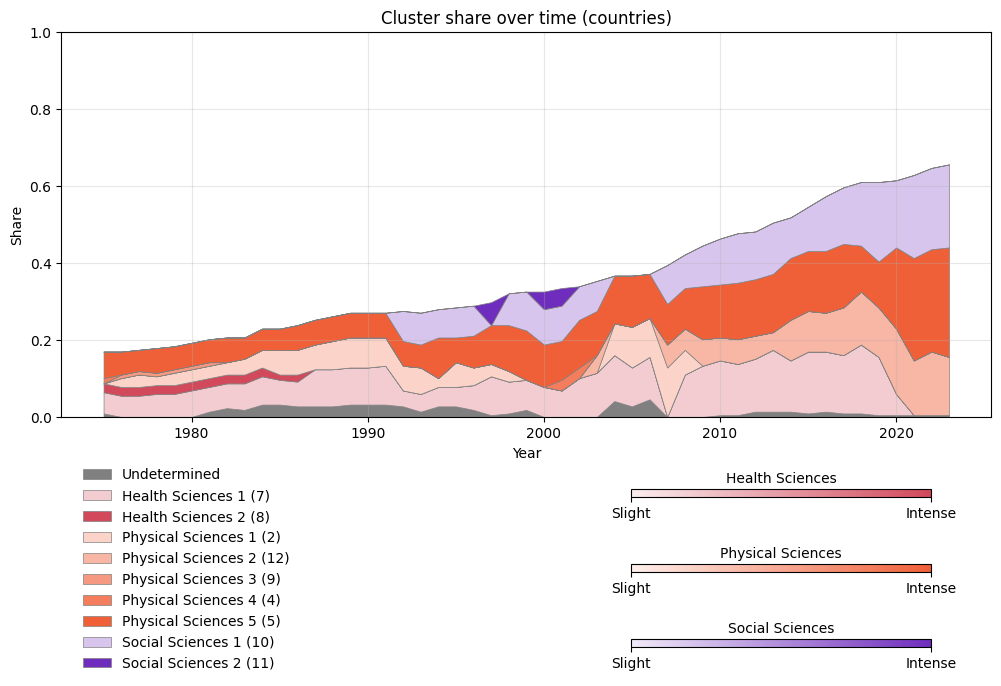

In [35]:
names_dict_cluster = {
    -1: "Not analysed",
    0: "Undetermined",
}

count_dict = {}
for cluster_loop in df_cluster_spec.cluster:
    # print(cluster_loop)
    # name = df_cluster_spec.query("cluster == @cluster_loop").iloc[0].field_name
    name = df_cluster_spec.query("cluster == @cluster_loop").iloc[0].domain_name
    if not (name in count_dict.keys()):
        count_dict[name] = 1
    else:
        count_dict[name] += 1
    names_dict_cluster[cluster_loop] = name+" "+str(count_dict[name])+f" ({int(cluster_loop)})"

df_stats_cluster["cluster"] = df_stats_cluster["cluster"].astype(int)

# --- 3. Add cluster names ---
df_plot = df_stats_cluster.copy()
df_plot["cluster_name"] = df_plot["cluster"].map(names_dict_cluster)
df_plot["cluster_name"] = df_plot["cluster_name"].fillna("Undefined")

# --- 4. Build color map with names ---
color_map_named = {
    names_dict_cluster[k]: color_dict_cluster[k]
    for k in color_dict_cluster
}
color_map_named["Undefined"] = "lightgrey"

# --- 5. Pivot to wide format ---
df_wide = (
    df_plot
    .pivot(index="year", columns="cluster_name", values="countries_share")
    .fillna(0)
)

# --- 6. Define consistent order ---
cluster_order = list(names_dict_cluster.values())

# keep only existing columns
cluster_order = [c for c in cluster_order if c in df_wide.columns]

df_wide = df_wide[cluster_order]

# --- 7. Plot stacked area ---
fig, ax = plt.subplots(figsize=(12, 5))

polys = ax.stackplot(
    df_wide.index,
    df_wide.T.values,
    labels=df_wide.columns,
    colors=[color_map_named[c] for c in df_wide.columns],
    edgecolor="grey",
)
for poly in polys:
    poly.set_linewidth(0.5)

# --- 8. Styling ---
ax.set_ylim(0, 1)
ax.set_xlabel("Year")
ax.set_ylabel("Share")
ax.set_title("Cluster share over time (countries)")

ax.legend(loc="upper left", bbox_to_anchor=(0.01, -0.1), frameon=False)
ax.grid(alpha=0.3)

# define normalization (same scale for all if needed)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

# create mappables
domain_list = df_cluster_spec.domain_name.unique()
for i, domain in enumerate(domain_list):
    j = i // 2
    k = i % 2
    sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0), norm=norm)
    # sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(from_color_list(colors_domain[domain]), 0.2, 1.0), norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.6, -0.05 - 0.15 * i, 0.25, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.ax.xaxis.set_label_position('top')
    cbar.set_label(domain, labelpad=5)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])


# plt.tight_layout()
plt.show()

In [36]:
# df_plot_appearance = (
#     df_map_analysis
#     .groupby("country")
#     .year.min().to_frame("first_year")
#     .reset_index()
#     .merge(df_map_analysis, left_on=["country", "first_year"], right_on=["country", "year"])
#     .groupby(["cluster", "year"], as_index=False)
#     .country
#     .count()
#     .assign(country_cumsum=lambda df: df.groupby(["cluster"]).country.transform(lambda x: x.cumsum()))
# )

# # --- 1. Ensure clusters are integers ---
# df_stats_cluster["cluster"] = df_stats_cluster["cluster"].astype(int)

# # --- 3. Add cluster names ---
# df_plot = df_plot_appearance.query("year > 1975").copy()
# df_plot["cluster_name"] = df_plot["cluster"].map(names_dict_cluster)
# df_plot["cluster_name"] = df_plot["cluster_name"].fillna("Undefined")

# # --- 4. Build color map with names ---
# color_map_named = {
#     names_dict_cluster[k]: color_dict_cluster[k]
#     for k in color_dict_cluster
# }
# color_map_named["Undefined"] = "lightgrey"

# # --- 5. Pivot to wide format ---
# df_wide = (
#     df_plot
#     .pivot(index="year", columns="cluster_name", values="country")
#     .fillna(0)
# )

# # --- 6. Define consistent order ---
# cluster_order = list(names_dict_cluster.values())

# # keep only existing columns
# cluster_order = [c for c in cluster_order if c in df_wide.columns]

# df_wide = df_wide[cluster_order]

# # --- 7. Plot stacked area ---
# fig, ax = plt.subplots(figsize=(10, 5))

# ax.stackplot(
#     df_wide.index,
#     df_wide.T.values,
#     labels=df_wide.columns,
#     colors=[color_map_named[c] for c in df_wide.columns],
#     # edgecolor="grey",
# )
# # for poly in polys:
# #     poly.set_linewidth(0.5)
# # --- 8. Styling ---
# # ax.set_ylim(0, 1)
# ax.set_xlabel("Year")
# ax.set_ylabel("N_countries")
# ax.set_title("New countries by clusters")

# ax.legend(title="Cluster", loc="upper left", bbox_to_anchor=(1, 1))
# ax.grid(alpha=0.3)

# # define normalization (same scale for all if needed)
# norm = mpl.colors.Normalize(vmin=0, vmax=1)

# # create mappables
# domain_list = df_cluster_spec.domain_name.unique()
# for i, domain in enumerate(domain_list):
#     j = i // 2
#     k = i % 2
#     sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0), norm=norm)
#     # sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(from_color_list(colors_domain[domain]), 0.2, 1.0), norm=norm)
#     sm.set_array([])
#     cax = fig.add_axes([0.2 + 0.1 * k + 0.25 * k, -0.02 - 0.15 * j, 0.25, 0.015])
#     cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
#     cbar.set_label(domain)
#     cbar.set_ticks([0, 1])
#     cbar.set_ticklabels(["Slight", "Intense"])

# # plt.tight_layout()
# plt.show()

/var/folders/kq/3vlmcmh917x4z481rl4yj6t00000gn/T/ipykernel_34963/2409604422.py:66: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



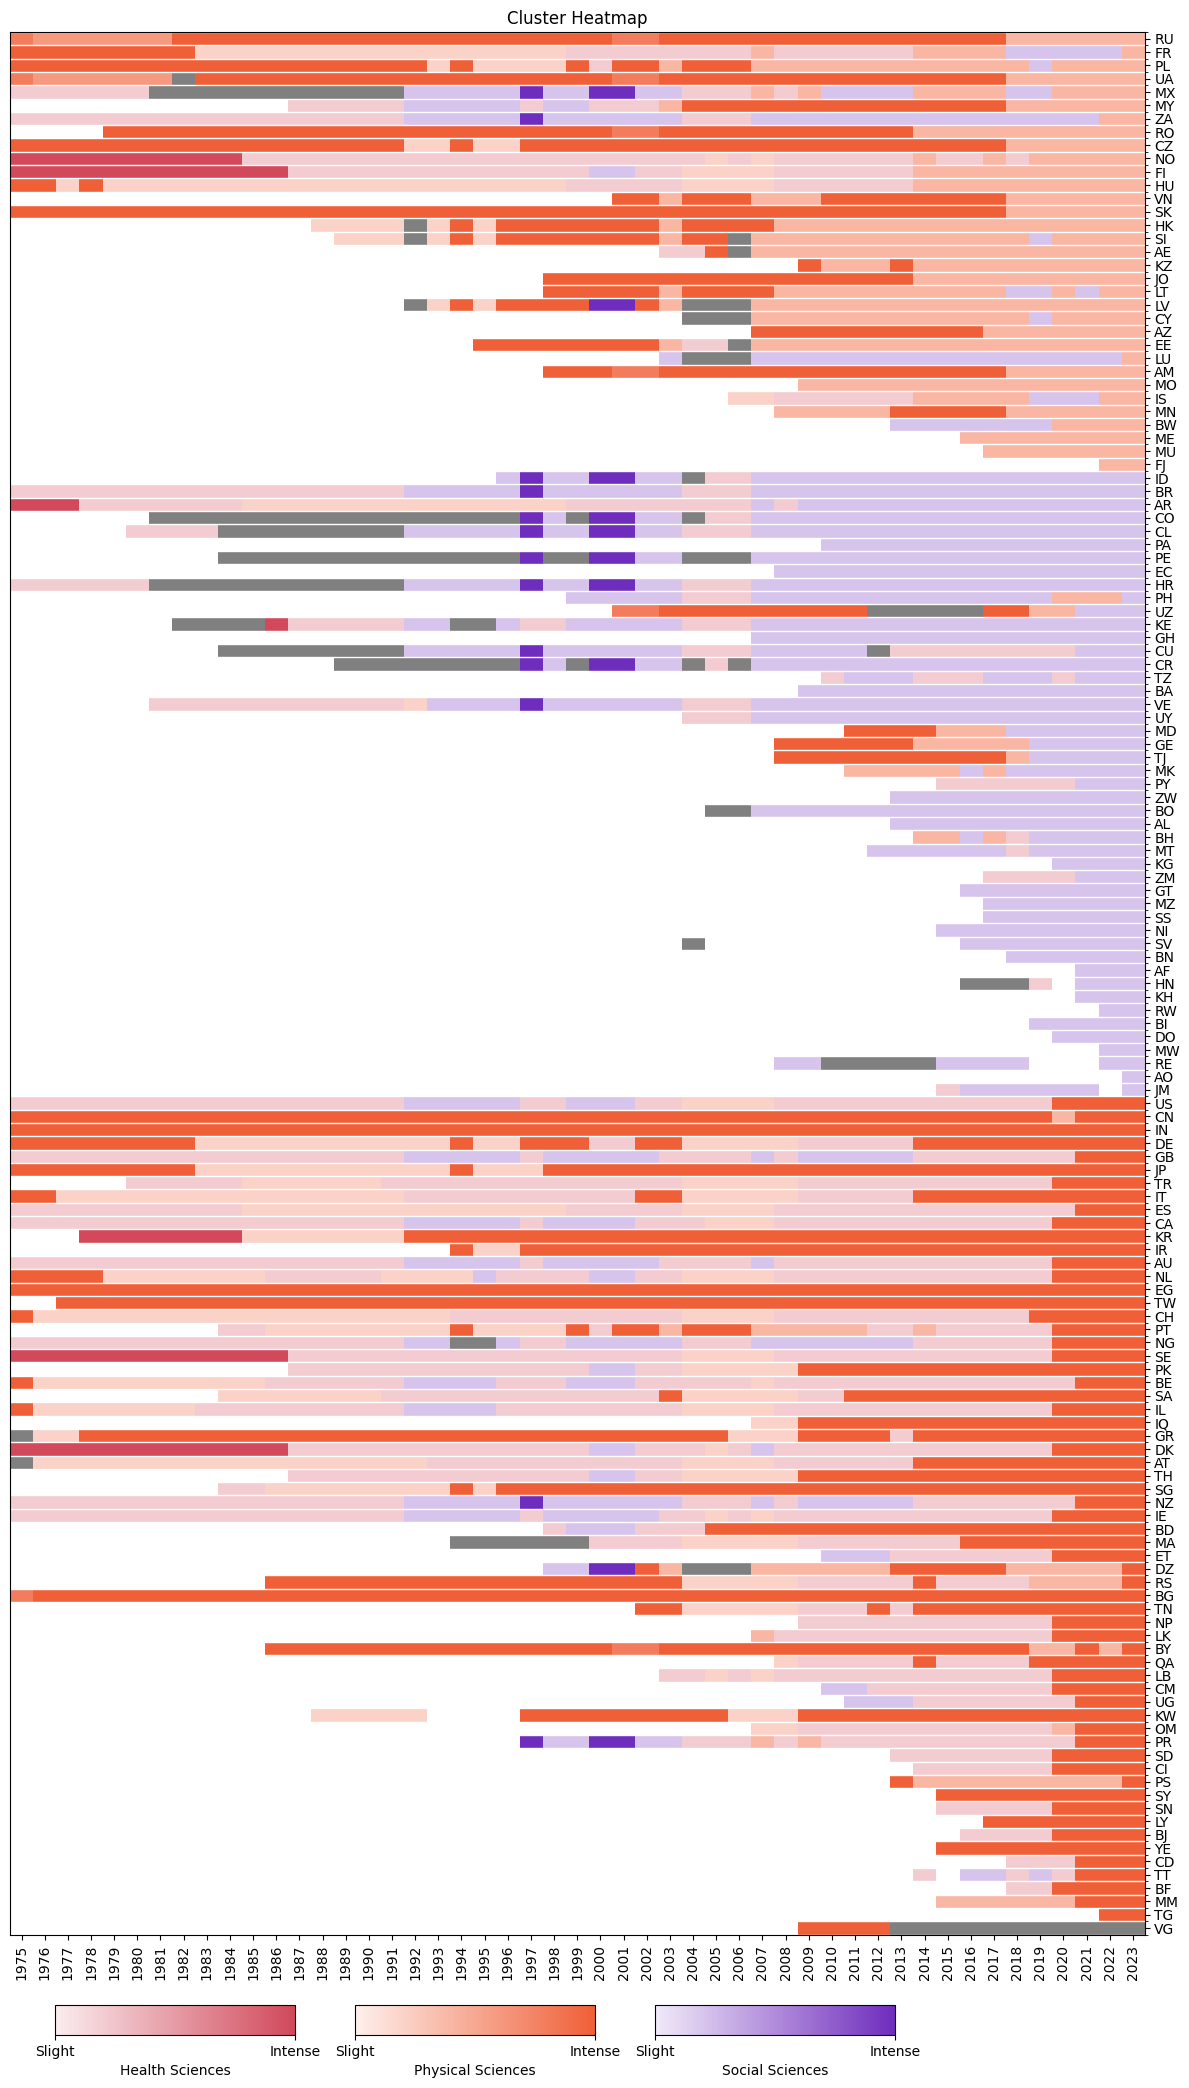

In [37]:
year = 2023
y_label = (
    df_map_analysis
    .merge(df_cs_yearly.sum(axis=1).to_frame("total"), left_on=["country", "year"], right_index=True)
    .query("year == @year").sort_values(["cluster", "total"], ascending=False)
    .country
    .to_list()
)

df_plot = (
    df_map_analysis
    .pivot(index="country", columns="year", values="cluster")
    .loc[y_label]
)
# --- 1. Map clusters to indices ---
clusters = sorted(color_dict_cluster.keys())
clusters_with_missing = clusters

color_list = [color_dict_cluster[cl] for cl in clusters_with_missing]
cmap = mcolors.ListedColormap(color_list)

# --- 5. Plot heatmap ---
fig, ax = plt.subplots(figsize=(12, 20))

cluster_to_idx = {c: i for i, c in enumerate(clusters)}

im = ax.imshow(
    df_plot.fillna(-1).replace(cluster_to_idx).values,
    aspect="auto",
    cmap=cmap,
)

# --- 6. Axis labels ---
ax.set_xticks(range(len(df_plot.columns)))
ax.set_xticklabels(df_plot.columns, rotation=90)

ax.set_yticks(range(len(df_plot.index)))
ax.set_yticklabels(df_plot.index)

ax.set_title("Cluster Heatmap")


ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")

n_rows, n_cols = df_plot.shape
ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
ax.grid(which="minor", axis="y", color="white", linewidth=1)
ax.tick_params(which="minor", left=False)

# define normalization (same scale for all if needed)
norm = mpl.colors.Normalize(vmin=0, vmax=1)

# create mappables
domain_list = df_cluster_spec.domain_name.unique()
for i, domain in enumerate(domain_list):
    sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0), norm=norm)
    # sm = mpl.cm.ScalarMappable(cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.2, 1.0), norm=norm)
    sm.set_array([])
    cax = fig.add_axes([0.05 + 0.05 * i + 0.2 * i, -0.02, 0.2, 0.015])
    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.set_label(domain)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])

plt.tight_layout()
plt.show()

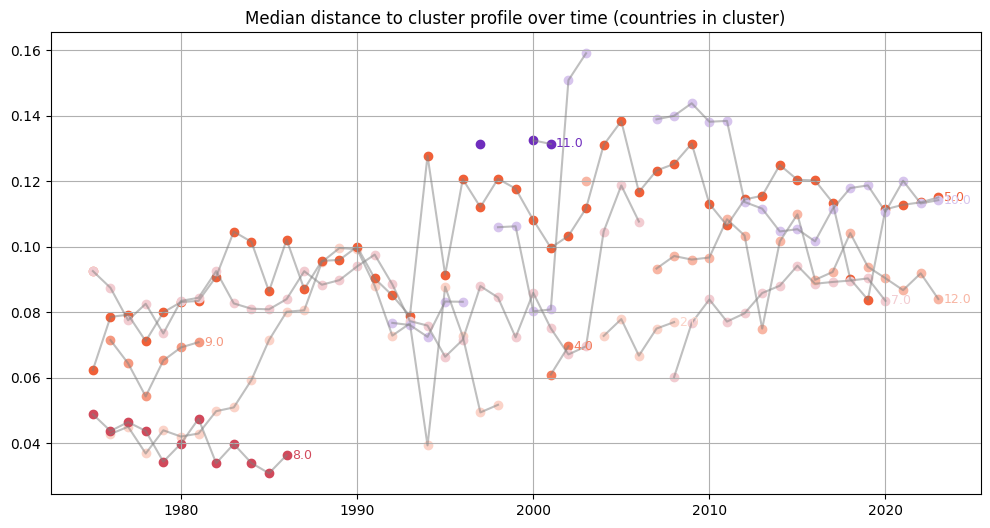

In [38]:
plt.subplots(figsize=(12, 6))
df_plot = df_dist_country_cluster.query("(in_cluster == 1) and (cluster_dist != 0)").groupby(["cluster_dist", "year"], as_index=False).value.median()
for cluster_loop in all_clusters:
    if cluster_loop == 0:
        continue
    df_plot_cluster = df_plot.query("cluster_dist == @cluster_loop").set_index("year").reindex(year_list).reset_index()
    plt.plot(year_list, df_plot_cluster.value, label=names_dict_cluster[cluster_loop], color="grey", alpha=0.5)
    plt.scatter(year_list, df_plot_cluster.value, label=names_dict_cluster[cluster_loop], color=color_dict_cluster[cluster_loop])

    if df_plot_cluster.dropna(subset=["value"]).empty:
        continue
    last_x = df_plot_cluster.dropna(subset=["value"]).year.iloc[-1]
    last_y = df_plot_cluster.dropna(subset=["value"]).value.iloc[-1]

    plt.text(
        last_x + 0.3,   # shift right a bit
        last_y,
        f"{cluster_loop}",   # 👈 cluster number
        color=color_dict_cluster[cluster_loop],
        va="center",
        fontsize=9
    )
# plt.legend()
plt.grid()
_ = plt.title("Median distance to cluster profile over time (countries in cluster)")

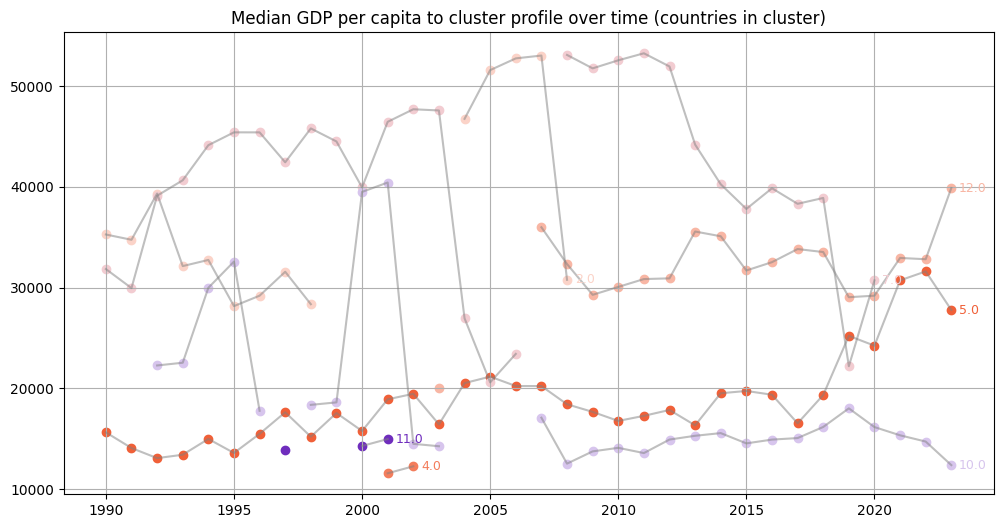

In [39]:
df_plot = (
    df_gdp_yearly
    .rename(columns={"GDP per capita": "gdp_per_capita"})
    .merge(df_map_analysis.merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"), left_index=True, right_on=["alpha-3", "year"])
    [["country", "year", "alpha-3", "gdp_per_capita", "cluster"]]
    .groupby(["cluster", "year"], as_index=False).gdp_per_capita.median()
    .query("cluster != 0")
)

plt.subplots(figsize=(12, 6))
# df_plot = df_dist_country_cluster.query("(in_cluster == 1) and (cluster_dist != 0)").groupby(["cluster_dist", "year"], as_index=False).value.median()
for cluster_loop in all_clusters:
    if cluster_loop == 0:
        continue
    df_plot_cluster = df_plot.query("cluster == @cluster_loop").set_index("year").reindex(year_list).reset_index()
    
    plt.plot(year_list, df_plot_cluster.gdp_per_capita, label=names_dict_cluster[cluster_loop], color="grey", alpha=0.5)
    plt.scatter(year_list, df_plot_cluster.gdp_per_capita, label=names_dict_cluster[cluster_loop], color=color_dict_cluster[cluster_loop])
    if df_plot_cluster.dropna(subset=["gdp_per_capita"]).empty:
        continue
    last_x = df_plot_cluster.dropna(subset=["gdp_per_capita"]).year.iloc[-1]
    last_y = df_plot_cluster.dropna(subset=["gdp_per_capita"]).gdp_per_capita.iloc[-1]

    plt.text(
        last_x + 0.3,   # shift right a bit
        last_y,
        f"{cluster_loop}",   # 👈 cluster number
        color=color_dict_cluster[cluster_loop],
        va="center",
        fontsize=9
    )
# plt.legend()
plt.grid()
_ = plt.title("Median GDP per capita to cluster profile over time (countries in cluster)")

# Year 

In [40]:
year = 2023

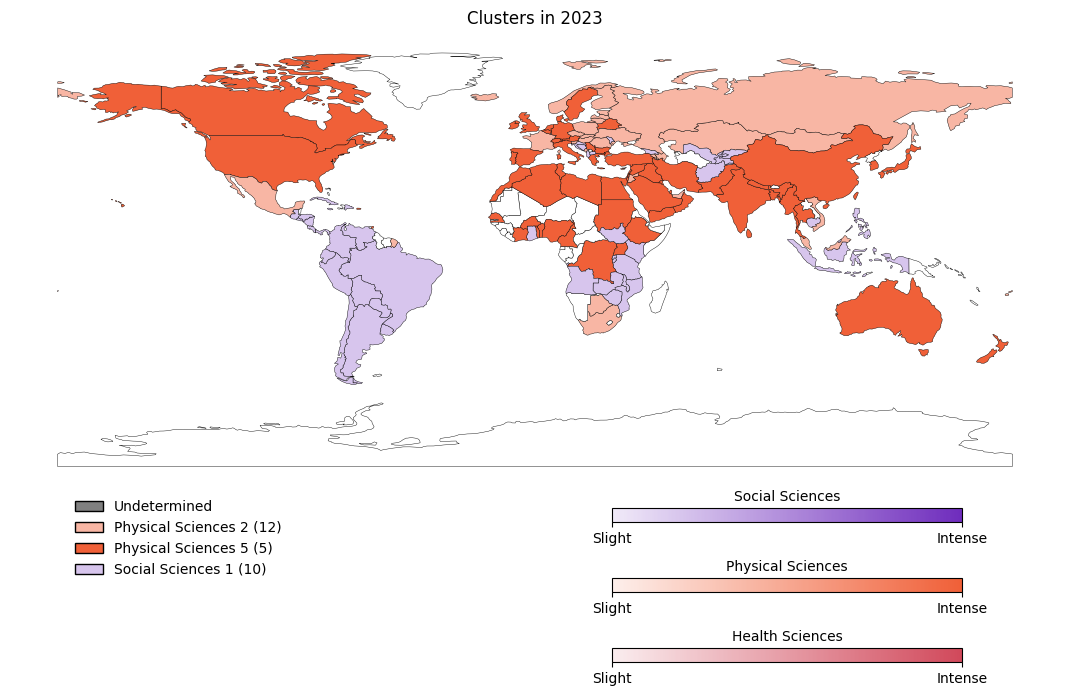

In [143]:
# map with clusters
# --- 4. Merge with world map ---
world = world_url.merge(
    df_map_analysis.query("year == @year").merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"),
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Map cluster → color ---
world["color"] = world["cluster"].map(color_dict_cluster)

# fallback for missing
world["color"] = world["color"].fillna("white")

legend_elements = []
for cluster, color in color_dict_cluster.items():
    if cluster in df_map_analysis.query("year == @year").cluster.to_list():
        label = names_dict_cluster.get(cluster, str(cluster))
        
        legend_elements.append(
            Patch(facecolor=color, edgecolor="black", label=label)
        )

fig, ax = plt.subplots(figsize=(14, 7))
fig.set_constrained_layout(False)

fig.subplots_adjust(left=0.05, right=0.8, top=0.9, bottom=0.25)

world.plot(
    color=world["color"],
    edgecolor="black",
    linewidth=0.3,
    ax=ax
)

ax.set_axis_off()
ax.set_title(f"Clusters in {year}")
ax.set_aspect('auto')

# --- legend ---
ax.legend(
    handles=legend_elements,
    # title="Cluster",
    loc="upper left",
    bbox_to_anchor=(0.05, 0),
    frameon=False
)

# --- colorbars ---
for i, domain in enumerate(domain_list):
    j = i // 2
    k = i % 2
    # cax = fig.add_axes([0.15 + 0.35 * k, 0.05 + 0.08 * j, 0.25, 0.02])
    cax = fig.add_axes([0.48, 0 + 0.1 * i, 0.25, 0.02])

    sm = mpl.cm.ScalarMappable(
        cmap=truncate_cmap(white_to_color(colors_domain[domain]), 0.1, 1.0),
        norm=norm
    )
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cax, orientation="horizontal")
    cbar.ax.xaxis.set_label_position('top')
    cbar.set_label(domain, labelpad=5)
    cbar.set_ticks([0, 1])
    cbar.set_ticklabels(["Slight", "Intense"])

plt.show()

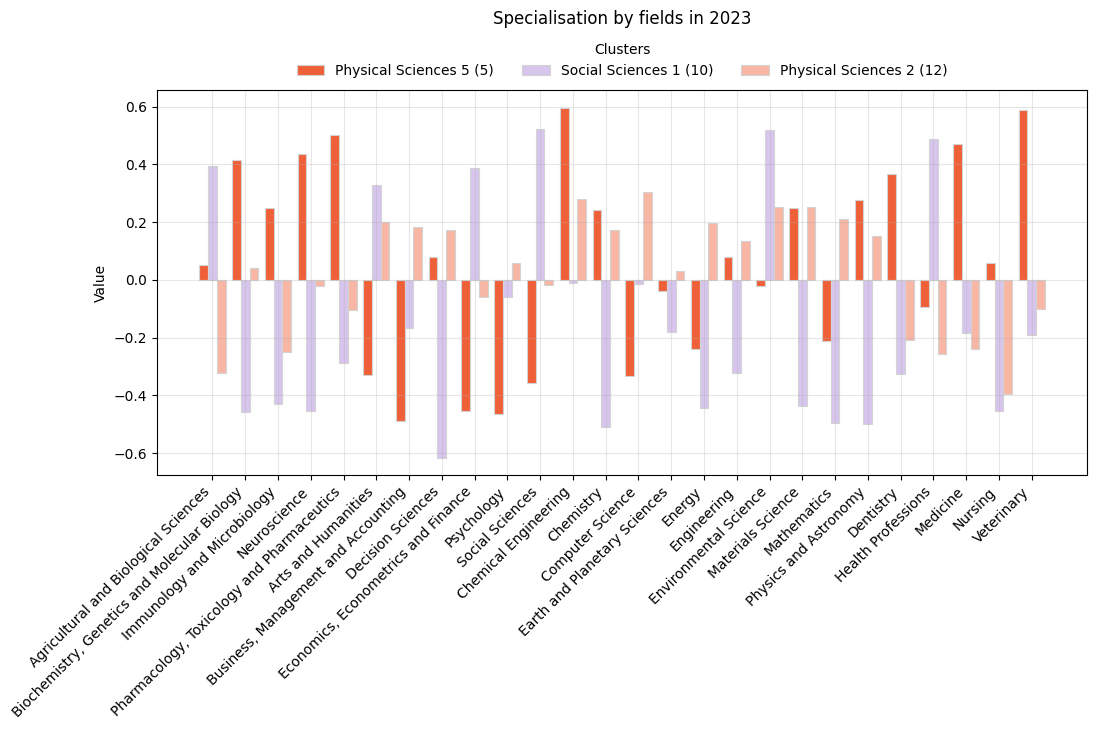

In [42]:
df_plot = (
    df_profile_norm_spec_fields_yearly.xs(year, level=1).reset_index()
    .melt(id_vars=["cluster"], var_name="field_name",).query("(cluster != 0) and (field_name != \"year\")")
)

clusters = sorted(df_plot["cluster"].unique())
fields = df_plot["field_name"].unique()

x = np.arange(len(fields))
width = 0.8 / len(clusters)  # total width split across clusters

fig, ax = plt.subplots(figsize=(12, 5))

for i, cluster in enumerate(clusters):
    df_sub = df_plot[df_plot["cluster"] == cluster]
    
    # ensure correct order of fields
    df_sub = df_sub.set_index("field_name").reindex(fields)

    ax.bar(
        x + i * width,
        df_sub["value"],
        width=width,
        label=names_dict_cluster[cluster],
        color=color_dict_cluster.get(cluster, "grey"),
        edgecolor="lightgrey",     # 👈 border color
        linewidth=0.8         # 👈 border thickness
    )

# --- formatting ---
ax.set_xticks(x + width * (len(clusters)-1)/2)
ax.set_xticklabels(fields, rotation=45, ha="right")

ax.set_ylabel("Value")

n_rows = (len(clusters)-1) // 4

ax.legend(title="Clusters",
          loc="lower center",
          bbox_to_anchor=(0.5, 1),
          ncol=4,
          frameon=False)   # push outside to the right)
ax.grid( alpha=0.3)
ax.set_title(f"Specialisation by fields in {year}", y=1.15+0.1*(n_rows))

# plt.tight_layout()
plt.show()

In [43]:
def plot_boxplot(ax, df, cluster_col, y_col, title):
    clusters = sorted(df[cluster_col].unique())

    data = [
        df[df[cluster_col] == c][y_col].values
        for c in clusters
    ]

    colors = [color_dict_cluster[cl] for cl in clusters]

    bp = ax.boxplot(
        data,
        patch_artist=True,
        tick_labels=clusters
    )

    # style boxes
    for box, color in zip(bp["boxes"], colors):
        box.set_facecolor(color)
        box.set_edgecolor("black")
        box.set_linewidth(1)

    # medians
    for median in bp["medians"]:
        median.set_color("black")
        median.set_linewidth(1.5)

    # whiskers & caps
    for whisker in bp["whiskers"]:
        whisker.set_color("black")

    for cap in bp["caps"]:
        cap.set_color("black")

    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

In [44]:
df1 = df_dist_country_cluster.query(
    "(year == @year) and (cluster_dist != 0) and (in_cluster == 1)"
)

df2 = (
    df_cs_yearly
    .sum(axis=1)
    .to_frame("total")
    .query("total > 0")
    .assign(log_total=lambda df: np.log(df.total))
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
    .query("(year == @year) and (cluster != 0)")
)

df3 = (
    df_prob_yearly.fillna(0)
    .apply(uf.gini, axis=1)
    .to_frame("gini_country")
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
    .query("(year == @year) and (cluster != 0)")
)

df4 = (
    df_gdp_yearly
    .rename(columns={"GDP per capita": "gdp_per_capita"})
    .merge(df_map_analysis.merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"), left_index=True, right_on=["alpha-3", "year"])
    [["country", "year", "alpha-3", "gdp_per_capita", "cluster"]]
    .query("year == @year")
)

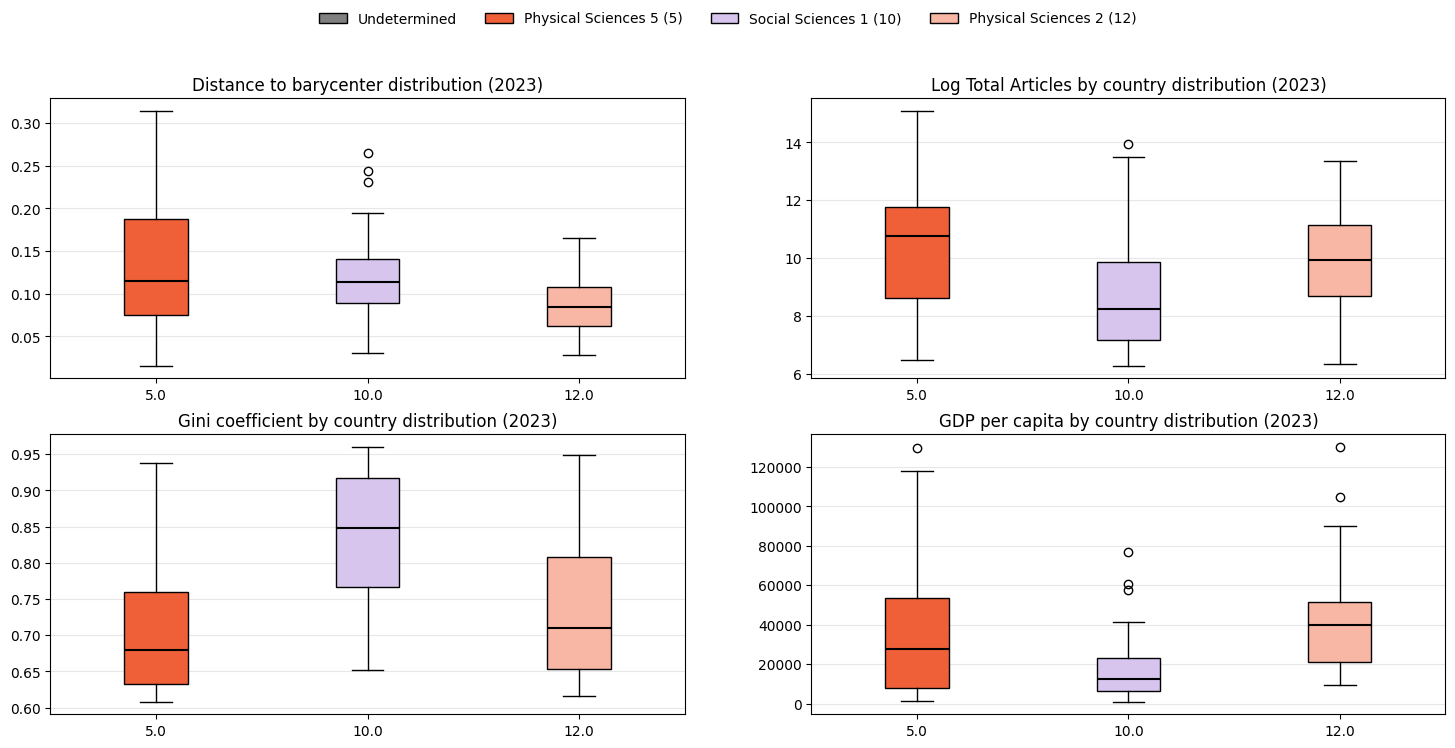

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharey=False)

plot_boxplot(
    axes[0, 0],
    df1,
    cluster_col="cluster_dist",
    y_col="value",
    title=f"Distance to barycenter distribution ({year})"
)

plot_boxplot(
    axes[0, 1],
    df2,
    cluster_col="cluster",
    y_col="log_total",
    title=f"Log Total Articles by country distribution ({year})"
)

plot_boxplot(
    axes[1, 0],
    df3,
    cluster_col="cluster",
    y_col="gini_country",
    title=f"Gini coefficient by country distribution ({year})"
)

plot_boxplot(
    axes[1, 1],
    df4,
    cluster_col="cluster",
    y_col="gdp_per_capita",
    title=f"GDP per capita by country distribution ({year})"
)


from matplotlib.patches import Patch

legend_handles = [
    Patch(facecolor=color_dict_cluster[cl], edgecolor="black",
          label=names_dict_cluster[cl])
    for cl in df_map_analysis.query("year == @year").cluster.drop_duplicates().sort_values().to_list()
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=len(legend_handles),
    frameon=False,
)

# plt.tight_layout(rect=[0, 0, 1, 0.9])  # leave space for legend
plt.show()

In [46]:
df_cs_yearly_full = pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col=[0, 1, 2])
df_prob_yearly_full = df_cs_yearly_full.div(df_cs_yearly_full.sum(axis=1), axis=0)

n_years = 5

df_cs_roll_yearly_full = (
    df_cs_yearly_full
    # .sort_index()
    .groupby(level=[0, 2])
    .rolling(n_years).sum()
    .reset_index(level=[0, 1], drop=True)
)
df_prob_roll_yearly_full = df_cs_roll_yearly_full.div(df_cs_roll_yearly_full.sum(axis=1), axis=0)

df_share = (df_cs_roll_yearly_full.sum(axis=1).to_frame("total").xs((year, "collaborative"), level=[1, 2]).dropna(how="all", axis=1) / (
    df_cs_roll_yearly_full.sum(axis=1).to_frame("total").xs((year, "individual"), level=[1, 2]).dropna(how="all", axis=1) +
    df_cs_roll_yearly_full.sum(axis=1).to_frame("total").xs((year, "collaborative"), level=[1, 2]).dropna(how="all", axis=1)
    
)).merge(df_map_analysis.query("(year == @year) and (cluster != 0)"), left_index=True, right_on="country", how="right")

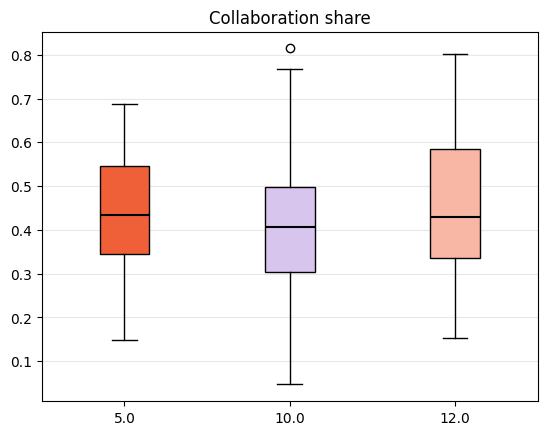

In [47]:
fig, ax = plt.subplots()
plot_boxplot(
    ax,
    df_share,
    cluster_col="cluster",
    y_col="total",
    title=f"Collaboration share"
)

# Cluster overview

In [102]:
cluster = 5
# 5, 14, 18

In [103]:
years_list = df_map_analysis.query("cluster == @cluster").year.drop_duplicates().sort_values().to_list()
years_list_full = range(years_list[0], years_list[-1]+1)

In [104]:
df_years = pd.DataFrame({}, index=years_list_full)
df_years.loc[years_list] = 1

In [105]:
total_countries = len(pd.read_csv(uf.PATH+"df_cs_yearly.csv", index_col = [0, 1, 2]).xs((2023, "individual"), level=[1, 2]).index)

df_pct_country = (
    pd.concat([
        df_map_analysis.query("year == @years_list and cluster == @cluster").groupby("year").country.count().to_frame("cluster"),
        df_map_analysis.query("year == @years_list").groupby("year").country.count().to_frame("all")
    ], axis=1)
    .assign(
        share_cluster = lambda df: df.cluster / total_countries,
        share_other = lambda df: (df.eval("all - cluster")) / total_countries)
)
# df_pct_country

In [106]:
df_pct_articles = (
    df_cs_yearly
    .merge(df_map_analysis.query("cluster == @cluster"), left_index=True, right_on=["country", "year"])
    .drop(columns=["country", "cluster"])
    .groupby(["year"])
    .sum()
    .sum(axis=1)
    .to_frame("share_cluster")
    .div(df_cs_yearly.sum(axis=1).groupby(level=1).sum().loc[years_list], axis=0)
    .assign(share_other = lambda df: 1 - df.share_cluster)
)
# df_pct_articles

In [107]:
bins = [0, 0.10, 0.50, 0.90, 1]
labels = [f"{int(bins[i]*100)}–{int(bins[i+1]*100)}%" for i in range(len(bins) - 1)]

df_cluster_country_count = (
    df_map_analysis
    .query("cluster == @cluster")
    .groupby("country", as_index=False)
    .year
    .count()
    .merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2", how="left")
    .assign(
        year_share = lambda df: df.year / len(years_list),
        year_cat = lambda df: pd.cut(
                                    df["year_share"],
                                    bins=bins,
                                    labels=labels,
                                    include_lowest=True
                                )
    )
)
# df_cluster_country_count

In [108]:
df_domains = (
    df_profile_yearly
    .xs(cluster, level=0)
    .T
    .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_id_str=lambda df: df.subfield_id.astype(str)),
           left_index=True, right_on="subfield_id_str")
    .drop(columns=["subfield_id", "subfield_id_str"])
    .groupby("domain_name")
    .sum()
    .T
    # .sum()
)

In [109]:
df_spec = (
    df_profile_yearly.xs(cluster, level=0)
    .sub(df_baricenter_global_yearly.loc[years_list])
    # .div(df_std_yearly.T.loc[df_baricenter_global_yearly.columns].T.loc[years_list])
)

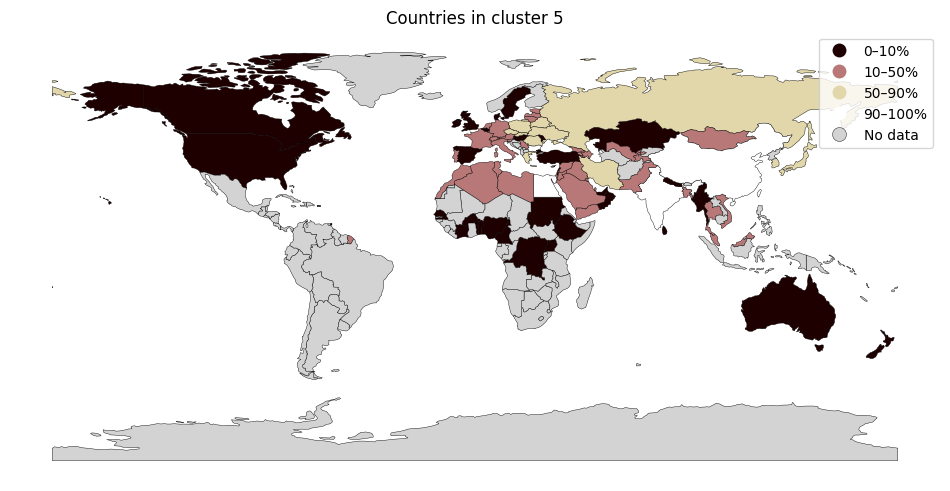

In [110]:
# --- 4. Merge with world map ---
world = world_url.merge(
    df_cluster_country_count,
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="year_cat",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Countries in cluster {cluster}")

plt.show()

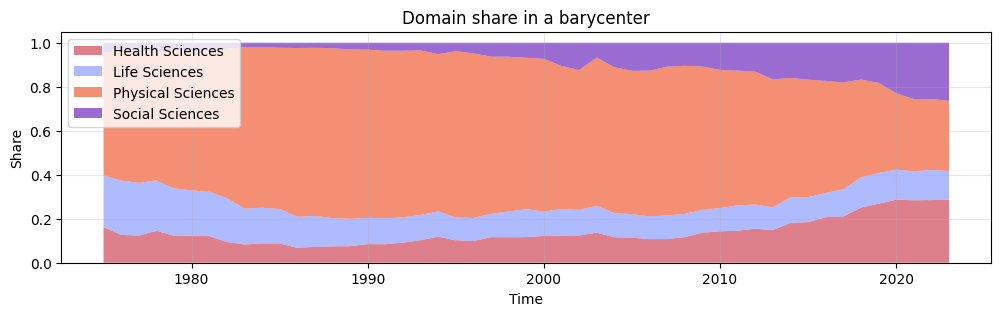

In [111]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 3))

x = df_domains.index.astype(int)
y1 = df_domains[df_domains.columns[0]]
y2 = df_domains[df_domains.columns[1]]
y3 = df_domains[df_domains.columns[2]]
y4 = df_domains[df_domains.columns[3]]

ax.stackplot(x, y1, y2, y3, y4, labels=df_domains.columns, alpha=0.7, colors=[colors_domain[c] for c in df_domains.columns])

ax.legend(loc="upper left")
ax.set_ylabel("Share")
ax.set_xlabel("Time")
ax.set_title("Domain share in a barycenter")
plt.grid(alpha=0.3)

plt.show()

In [112]:
# fig, ax = plt.subplots(figsize=(12, 3))
# plt.plot(df_gini_countries.index, df_gini_countries.cluster, label="Cluster")
# plt.plot(df_gini_countries.index, df_gini_countries["all"], label="Global")
# plt.grid(alpha=0.3)
# plt.ylabel("Gini")
# plt.legend()
# _ = plt.title("Gini coefficient by countries productivity")

In [113]:
# fig, ax = plt.subplots(figsize=(12, 3))
# plt.plot(df_gini_profiles.index, df_gini_profiles.cluster, label="Cluster")
# plt.plot(df_gini_profiles.index, df_gini_profiles["all"], label="Global")
# plt.grid(alpha=0.3)
# plt.ylabel("Gini")
# plt.legend()
# _ = plt.title("Gini coefficient by subfield profiles")

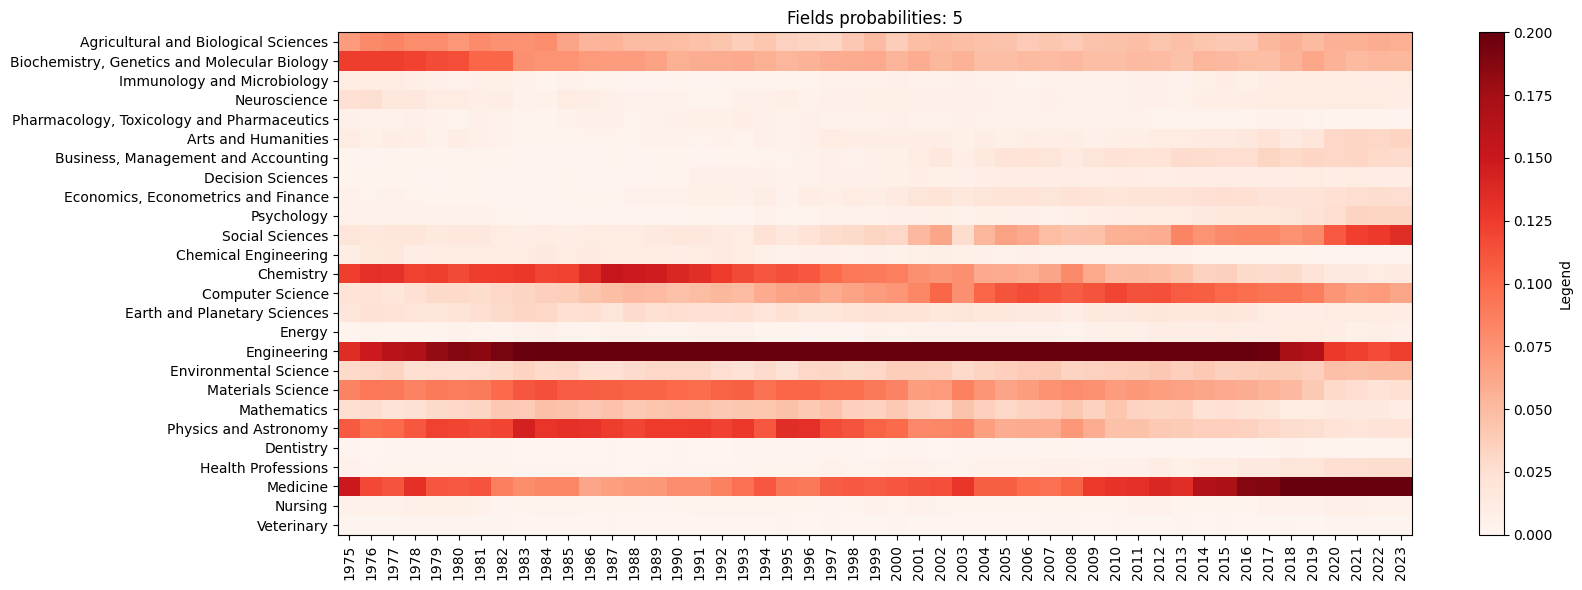

In [114]:
df_plot = get_prob_fields(df_profile_yearly.xs(cluster))
uf.plot_heatmap(df_plot.T, df_plot.index, df_plot.columns, line_height=10,
                # x_type="subfield",
                z_min=0, z_max=0.2, colorscale="non", title=f"Fields probabilities: {cluster}")

In [115]:
# uf.plotly_heatmap(
#     df_profile_yearly.xs(cluster),
#     x_labels=df_profile_yearly.xs(cluster).columns,
#     y_labels=df_profile_yearly.xs(cluster).index,
#     z_min=0,
#     z_max=0.02,
#     colorscale="non",
#     x_type="subfield"
# )

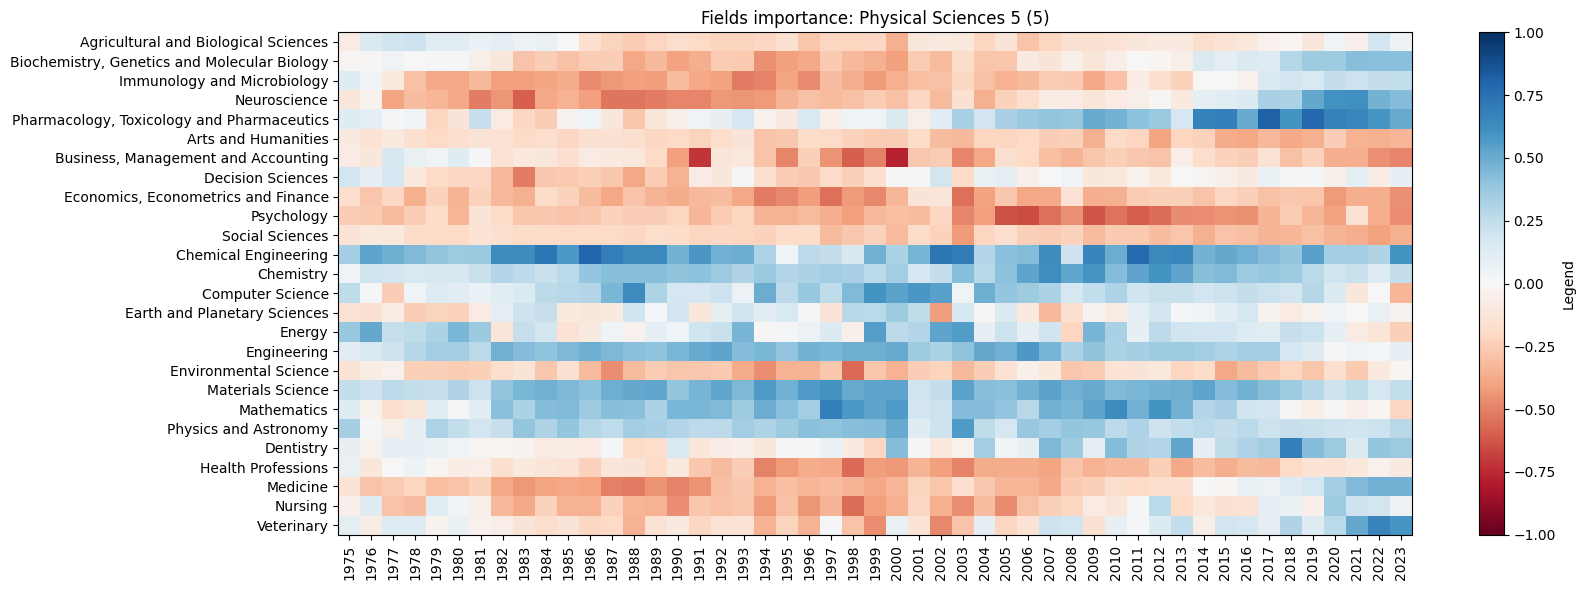

In [116]:
uf.plot_heatmap(df_profile_norm_spec_fields_yearly.xs(cluster).T, df_profile_spec_fields_yearly.xs(cluster).index, df_profile_spec_fields_yearly.xs(cluster).columns, line_height=10,
                # x_type="subfield",
                z_min=-1, z_max=1, colorscale="symm", title=f"Fields importance: {names_dict_cluster[cluster]}")

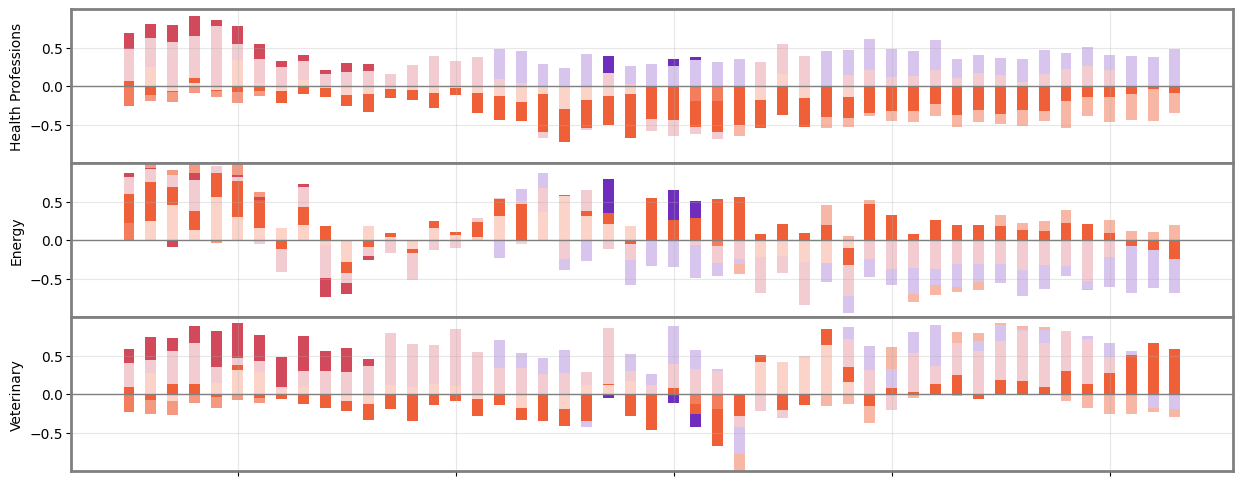

In [141]:
import numpy as np
import matplotlib.pyplot as plt

field_list = ["Health Professions", "Energy", "Veterinary"]

# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(field_list),
    ncols=1,
    figsize=(15, 2 * len(domain_list)),
    sharex=True
)

df_spec_years = df_profile_norm_spec_fields_yearly[field_list].reset_index().query("cluster != 0")

# If only one domain, make axes iterable
if len(field_list) == 1:
    axes = [axes]

for ax, field in zip(axes, field_list):
    # Prepare data
    df_plot = df_spec_years.pivot(index="year", columns="cluster", values=field)
    x = df_plot.index

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_plot))
    neg_sum = np.zeros(len(df_plot))

    # Plot stacked bars
    for cluster in df_plot.columns:
        y = df_plot[cluster].values

        y_pos = np.where(y > 0, y, 0)
        y_neg = np.where(y < 0, y, 0)

        color = color_dict_cluster.get(cluster, "grey")

        # Positive stack
        ax.bar(
            x, y_pos,
            bottom=pos_sum,
            color=color,
            width=0.5,
            # alpha=0.6
        )

        # Negative stack
        ax.bar(
            x, y_neg,
            bottom=neg_sum,
            color=color,
            width=0.5,
            # alpha=0.6
        )

        # Update stacks
        pos_sum += y_pos
        neg_sum += y_neg

    # Baseline
    ax.axhline(0, color="grey", linewidth=1)
    # ax.axhline(1, color="grey", linewidth=4)

    # Limits and labels
    ax.set_ylim(-1, 1)
    ax.set_ylabel(field)

    # Grid
    ax.set_yticks([-0.5, 0, 0.5])
    ax.tick_params(axis='y', pad=2)
    ax.grid(alpha=0.3)

# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes):
    # ax.spines['right'].set_visible(False)
    ax.spines["right"].set_color("grey")
    ax.spines["right"].set_linewidth(2)
    ax.spines["left"].set_color("grey")
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_color("grey")
    ax.spines["top"].set_linewidth(2)
    ax.spines["bottom"].set_color("grey")
    ax.spines["bottom"].set_linewidth(2)
    # Top spine only for first plot
    # if i == 0:
    #     ax.spines['top'].set_visible(True)
    # else:
    #     ax.spines['top'].set_visible(False)

    # Bottom spine only for last plot
    # if i == len(axes) - 1:
    #     ax.spines['bottom'].set_visible(True)
    # else:
    #     ax.spines['bottom'].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.set_xticklabels([])

# axes[-1].set_xticks(x)
# axes[-1].set_xticklabels(x)

plt.show()

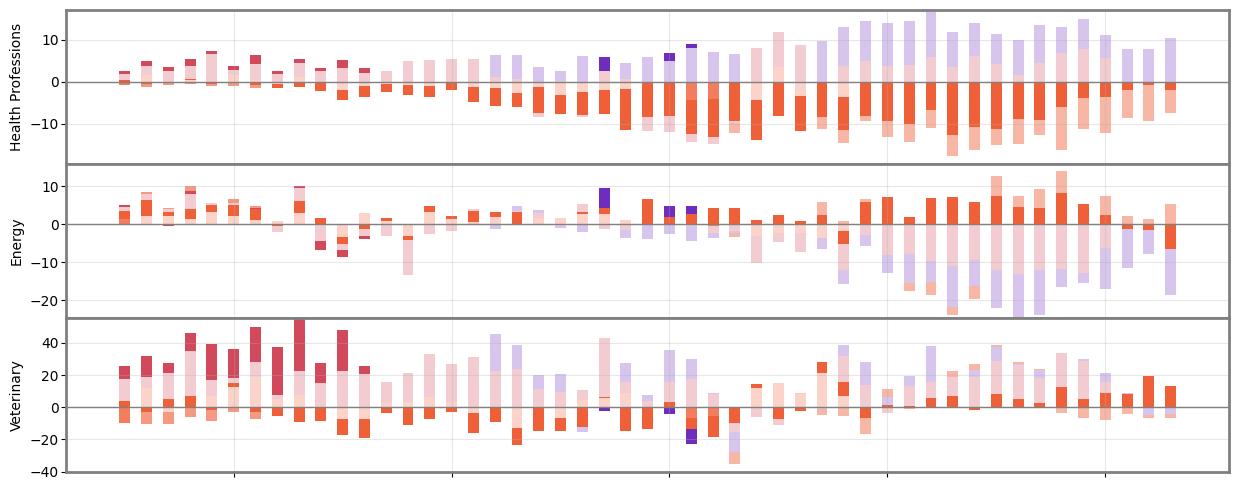

In [142]:
import numpy as np
import matplotlib.pyplot as plt

field_list = ["Health Professions", "Energy", "Veterinary"]

# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(field_list),
    ncols=1,
    figsize=(15, 2 * len(domain_list)),
    sharex=True
)

df_spec_years = df_profile_spec_fields_yearly[field_list].reset_index().query("cluster != 0")

# If only one domain, make axes iterable
if len(field_list) == 1:
    axes = [axes]

for ax, field in zip(axes, field_list):
    # Prepare data
    df_plot = df_spec_years.pivot(index="year", columns="cluster", values=field)
    x = df_plot.index

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_plot))
    neg_sum = np.zeros(len(df_plot))

    # Plot stacked bars
    for cluster in df_plot.columns:
        y = df_plot[cluster].values

        y_pos = np.where(y > 0, y, 0)
        y_neg = np.where(y < 0, y, 0)

        color = color_dict_cluster.get(cluster, "grey")

        # Positive stack
        ax.bar(
            x, y_pos,
            bottom=pos_sum,
            color=color,
            width=0.5,
            # alpha=0.6
        )

        # Negative stack
        ax.bar(
            x, y_neg,
            bottom=neg_sum,
            color=color,
            width=0.5,
            # alpha=0.6
        )

        # Update stacks
        pos_sum += y_pos
        neg_sum += y_neg

    # Baseline
    ax.axhline(0, color="grey", linewidth=1)
    # ax.axhline(1, color="grey", linewidth=4)

    # Limits and labels
    # ax.set_ylim(-1, 1)
    ax.set_ylabel(field)

    # Grid
    # ax.set_yticks([-0.5, 0, 0.5])
    ax.tick_params(axis='y', pad=2)
    ax.grid(alpha=0.3)

# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes):
    # ax.spines['right'].set_visible(False)
    ax.spines["right"].set_color("grey")
    ax.spines["right"].set_linewidth(2)
    ax.spines["left"].set_color("grey")
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_color("grey")
    ax.spines["top"].set_linewidth(2)
    ax.spines["bottom"].set_color("grey")
    ax.spines["bottom"].set_linewidth(2)
    # Top spine only for first plot
    # if i == 0:
    #     ax.spines['top'].set_visible(True)
    # else:
    #     ax.spines['top'].set_visible(False)

    # Bottom spine only for last plot
    # if i == len(axes) - 1:
    #     ax.spines['bottom'].set_visible(True)
    # else:
    #     ax.spines['bottom'].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.set_xticklabels([])

# axes[-1].set_xticks(x)
# axes[-1].set_xticklabels(x)

plt.show()

In [117]:
df_plot = df_dist_country_cluster.query("(cluster_dist == @cluster) and (in_cluster == 1)")
px.box(df_plot, x="year", y="value", title=f"Distance to barycenter in cluster {cluster}", hover_name="country")

In [118]:
df_plot = (
    df_prob_yearly.fillna(0)
    .apply(uf.gini, axis=1)
    .to_frame("gini_country")
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
)
px.box(df_plot.query("cluster == @cluster"), x="year", y="gini_country", hover_name="country", title=f"Gini by country in cluster {cluster}")

In [119]:
df_plot = (
    df_cs_yearly
    .sum(axis=1)
    .to_frame("total")
    .query("total > 0")
    .assign(log_total=lambda df: np.log(df.total))
    .merge(df_map_analysis, left_index=True, right_on=["country", "year"])
)
px.box(df_plot.query("cluster == @cluster"), x="year", y="log_total", hover_name="country", title=f"Log total articles by country in cluster {cluster}")

In [120]:
df_plot = (
    df_gdp_yearly
    .rename(columns={"GDP per capita": "gdp_per_capita"})
    .merge(df_map_analysis.merge(uf.df_country[["alpha-2", "alpha-3"]], left_on="country", right_on="alpha-2"), left_index=True, right_on=["alpha-3", "year"])
    [["country", "year", "alpha-3", "gdp_per_capita", "cluster"]]
)
px.box(df_plot.query("cluster == @cluster"), x="year", y="gdp_per_capita", hover_name="country", title=f"GDP per capita by country in cluster {cluster}")

# Country overview

In [573]:
country = "US"

year_list = df_map_analysis.query("country == @country").year.drop_duplicates().sort_values().to_list()
country_clusters = df_map_analysis.query("country == @country").cluster.drop_duplicates().sort_values().to_list()

In [574]:
df_profile_country = df_prob_yearly.xs(country, level=0).loc[year_list]

In [575]:
uf.plotly_heatmap(df_profile_country, x_labels=df_profile_country.columns, y_labels=year_list, colorscale="non", z_min=0, z_max=0.02, line_height=10, title=country)

In [576]:
df_gl = (
    df_baricenter_global_yearly
    .loc[year_list]
    .apply(uf.gini, axis=1)
    .to_frame("global")
)
df_cl = (
    df_map_analysis
    .query("country == @country")
    .merge(df_profile_yearly, left_on=["cluster", "year"], right_index=True, how="left")
    .drop(columns=["country", "cluster"])
    .set_index("year")
    .apply(uf.gini, axis=1)
    .to_frame("cluster")
)

df_c = (
    df_profile_country
    .apply(uf.gini, axis=1)
    .to_frame(country)
)

df_gini = pd.concat([df_gl, df_cl, df_c], axis=1)

In [577]:
cluster_list = df_map_analysis.query("country == @country").cluster.drop_duplicates().to_list()
cluster_labels = dict(zip(cluster_list ,["Cluster "+str(cl) if cluster_list[cl-1] != 0 else "Undefined" for cl in range(1, len(cluster_list)+1)]))
cluster_colors = dict(zip(cluster_list, cmap(np.linspace(0, 1, len(cluster_labels)))))

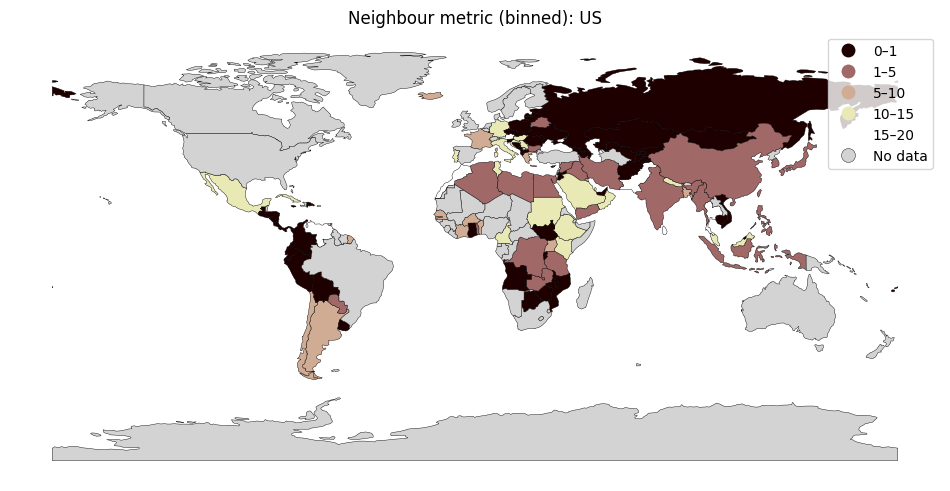

In [578]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Define bins ---
bins = [0, 1, 5, 10, 15, 20]
labels = [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins) - 1)]

# --- 2. Prepare data ---
df_plot_neighbours = (
    df_neighbours_counts
    .loc[country]
    .sort_values(ascending=False)
    .to_frame("years")
    .merge(
        uf.df_country[["alpha-2", "alpha-3"]],
        left_index=True,
        right_on="alpha-2",
        how="left"
    )
)

# --- 3. Create categorical variable ---
df_plot_neighbours["years_category"] = pd.cut(
    df_plot_neighbours["years"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- 4. Merge with world map ---
world = world_url.merge(
    df_plot_neighbours,
    left_on="ISO_A3_EH",
    right_on="alpha-3",
    how="left"
)

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(12, 6))

world.plot(
    column="years_category",   # categorical column
    cmap="pink",            # automatically applied
    legend=True,               # clean legend
    edgecolor="black",
    linewidth=0.3,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# --- 6. Styling ---
ax.set_axis_off()
ax.set_title(f"Neighbour metric (binned): {country}")

plt.show()

# 10Y overview

In [646]:
df_map_analysis.cluster.nunique()

9

In [647]:
year_list_10y = np.arange(2023, 1975, -5)
# year_list_10y = np.arange(2023, 2002, -2)

In [648]:
df_map_analysis.query("year in @year_list_10y")

,year,country,cluster
58,1978,AU,2.0
59,1978,BE,4.0
60,1978,CA,1.0
61,1978,CH,3.0
62,1978,DE,3.0
...,...,...,...
3269,2023,VN,3.0
3270,2023,YE,3.0
3271,2023,ZA,2.0
3272,2023,ZM,0.0


In [649]:
df_cy_cluster = df_map_analysis.query("year in @year_list_10y").pivot(index="country", columns="year", values="cluster")

In [650]:
(
    df_cy_cluster
)

year,1978,1983,1988,1993,1998,2003,2008,2013,2018,2023
country,,,,,,,,,,
AE,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,6.0,3.0
AF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0
AL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,2.0
AM,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3.0,3.0
AR,NaN,NaN,NaN,3.0,4.0,4.0,3.0,2.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...
VN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,2.0,3.0,3.0
YE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,3.0
ZA,NaN,NaN,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0


In [651]:
df_tmp = (
    df_map_analysis.query("(year in @year_list_10y)")
    .groupby(["cluster", "year"], as_index=False).country.nunique()
    .sort_values(["year", "cluster"], ascending=[False, True])
    .assign(
        # total_countries=lambda df: df.groupby("year").country.transform("sum"),
        country_share=lambda df: df.country / df_cs_yearly.reset_index().country.nunique()
    )
    .reset_index(drop=True)
)

In [652]:
df_tmp.query("year == 2023")

,cluster,year,country,country_share
0,0.0,2023,13,0.059633
1,2.0,2023,39,0.178899
2,3.0,2023,53,0.243119
3,8.0,2023,41,0.188073


In [653]:
x_array = np.full(len(df_tmp), np.nan)
y_array = np.full(len(df_tmp), np.nan)
height_array = np.full(len(df_tmp), np.nan)
width_array = np.full(len(df_tmp), np.nan)
color_array = np.full(len(df_tmp), np.nan, dtype=object)
country_array = np.full(len(df_tmp), np.nan, dtype=object)
country_cluster_array = np.full(len(df_tmp), np.nan, dtype=object)

domain_list = ["Physical Sciences", "Health Sciences", "Social Sciences", "Life Sciences"]


In [654]:
color_dict_tmp = {
    0: "#9D9D9D",
    2: "#264653",
    5: "#287271",
    7: "#2A9D8F",
    8: "#E9C46A",
    10: "#F4A261",
    12: "#E76F51",
    4: "grey",
    11: "black",
    9: "yellow",
    3: "red",
    6: "blue",
    1: "cyan"
}

# color_dict_tmp = {
#     0: "9D9D9D",
#     2: "#264653",
#     5: "#287271",
#     7: "#2A9D8F",
#     8: "#E9C46A",
#     10: "#F4A261",
#     12: "#E76F51",
# }

In [655]:
total_share = df_tmp.query("year == 2023").country_share.sum()
width = 0.2

array_idx = 0
next_year_dict = {}
for i, year_loop in enumerate(year_list_10y):
    cluster_list_year = df_tmp.query("year == @year_loop").cluster.to_list()
    country_share_list = df_tmp.query("year == @year_loop").country_share.to_list()
    n_clusters = len(cluster_list_year)
    share_year = df_tmp.query("year == @year_loop").country_share.sum()
    # vert_space = (total_share - share_year) / (n_clusters + 1)
    vert_space = 0

    vert_coord = 0
    for j in range(n_clusters):
        # print(year_loop, cluster_list_year[j], country_share_list[j])
        x_array[array_idx] = len(year_list_10y) - i - width
        y_array[array_idx] = vert_coord + vert_space
        height_array[array_idx] = country_share_list[j]
        width_array[array_idx] = width  # width of the bar (10 years)
        color_array[array_idx] = color_dict_tmp[cluster_list_year[j]] if cluster_list_year[j] != 0 else "grey"
        vert_coord += country_share_list[j] + vert_space
        array_idx += 1

rectangles = list(tuple(zip(x_array, y_array, width_array, height_array)))
# rectangles_ps = list(tuple(zip(x_array_ps, y_array_ps, width_array_ps, height_array_ps)))

In [656]:
prev_y1 = {}
for k, year_loop in enumerate(year_list_10y[1:]):
    next_year_dict = {}
    year_next = year_list_10y[k]
    if k < len(year_list_10y) - 3:
        year_prev = year_list_10y[k+2]
        year_prev_prev = year_list_10y[k+3]
    elif k < len(year_list_10y) - 2:
        year_prev = year_list_10y[k+2]
        year_prev_prev = None
    else:
        year_prev = None
        year_prev_prev = None
    cluster_list_year = df_tmp.query("year == @year_loop").cluster.to_list()
    
    for i in range(len(cluster_list_year)):
        cluster_loop = cluster_list_year[i]
        if year_prev_prev is not None:
            df_cluster_year = (
                df_map_analysis.query("year == @year_loop")
                .merge(df_map_analysis.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(df_map_analysis.query("year == @year_prev"), on="country", how="left", suffixes=["", "_prev"])
                .merge(df_map_analysis.query("year == @year_prev_prev"), on="country", how="left", suffixes=["_cur", "_prev_prev"])
                .query("cluster_cur == @cluster_loop")
                .sort_values(["cluster_prev_prev", "cluster_prev", "cluster_next"])
                # .sort_values(["cluster_prev", "cluster_next"])
            )
        elif year_prev is not None:
            df_cluster_year = (
                df_map_analysis.query("year == @year_loop")
                .merge(df_map_analysis.query("year == @year_next"), on="country", how="left", suffixes=["", "_next"])
                .merge(df_map_analysis.query("year == @year_prev"), on="country", how="left", suffixes=["_cur", "_prev"])
                .query("cluster_cur == @cluster_loop")
                .sort_values(["cluster_prev", "cluster_next"])
                # .sort_values(["cluster_next"])
            )
        else:
            df_cluster_year = (
                df_map_analysis.query("year == @year_loop")
                .merge(df_map_analysis.query("year == @year_next"), on="country", how="left", suffixes=["_cur", "_next"])
                .query("cluster_cur == @cluster_loop")
                .sort_values(["cluster_next"])
            )
        # display(df_cluster_year)
        n_countries = len(df_cluster_year)
        cur_cluster_idx = df_tmp.query("(year == @year_loop) and (cluster == @cluster_loop)").index[0]
        # print(cur_cluster_idx)
        country_step = height_array[cur_cluster_idx] / n_countries

        x1_array = np.full(n_countries, np.nan)
        y1_array = np.full(n_countries, np.nan)
        x2_array = np.full(n_countries, np.nan)
        y2_array = np.full(n_countries, np.nan)
        c_array = np.full(n_countries, np.nan, dtype=object)

        x1_cluster_array = np.full(n_countries, np.nan)
        y1_cluster_array = np.full(n_countries, np.nan)
        x2_cluster_array = np.full(n_countries, np.nan)
        y2_cluster_array = np.full(n_countries, np.nan)
        c_cluster_array = np.full(n_countries, np.nan, dtype=object)

        next_year_list = df_cluster_year.cluster_next.dropna().unique().tolist()
        for next_cluster in next_year_list:
            if next_cluster not in next_year_dict:
                next_cluster_idx = df_tmp.query("(year == @year_next) and (cluster == @next_cluster)").index[0]
                next_year_dict[next_cluster] = y_array[next_cluster_idx]
       
        y_cur = y_array[cur_cluster_idx]
        for j, country in enumerate(df_cluster_year.country):
            next_cluster = df_cluster_year.query("country == @country").cluster_next.values[0]
            if country == "US":
                if country in prev_y1.keys():
                    print(year_loop, country, prev_y1[country], next_year_dict[next_cluster])
                else:
                    print(year_loop, country, "Not found", next_year_dict[next_cluster])
            # print(prev_y1.get(country, next_year_dict[next_cluster]))
            y1_array[j] = y_cur
            print(year_loop, country, next_cluster)
            if np.isnan(next_cluster):
                continue
            y2_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_array[j] = len(year_list_10y) - k - 1
            x2_array[j] = len(year_list_10y) - k - width
            c_array[j] = country

            y1_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            y2_cluster_array[j] = prev_y1.get(country, next_year_dict[next_cluster])
            x1_cluster_array[j] = len(year_list_10y) - k - width
            x2_cluster_array[j] = len(year_list_10y) - k
            c_cluster_array[j] = country

            prev_y1[country] = y_cur
            if country == "US":
                print(year_loop, country, prev_y1)

            y_cur += country_step
            next_year_dict[next_cluster] += country_step

        country_array[cur_cluster_idx] = list(tuple(zip(x1_array, y1_array, x2_array, y2_array, c_array)))
        country_cluster_array[cur_cluster_idx] = list(tuple(zip(x1_cluster_array, y1_cluster_array, x2_cluster_array, y2_cluster_array, c_cluster_array)))

    print(k, year_loop, year_next)

2018 VG 0.0
2018 KE 0.0
2018 TZ 0.0
2018 UG 0.0
2018 BF 0.0
2018 MW 0.0
2018 CD 0.0
2018 GD 0.0
2018 ML 0.0
2018 ZM 0.0
2018 GT 2.0
2018 RW 2.0
2018 CR 2.0
2018 PE 2.0
2018 PH 2.0
2018 UY 2.0
2018 CM 8.0
2018 ET 8.0
2018 NG 8.0
2018 PR 2.0
2018 IT 8.0
2018 EG 3.0
2018 GR 8.0
2018 BR 2.0
2018 CO 2.0
2018 CU 2.0
2018 IE 2.0
2018 LB 2.0
2018 NL 2.0
2018 NZ 2.0
2018 ZA 2.0
2018 NO 3.0
2018 AT 8.0
2018 AU 8.0
2018 BD 8.0
2018 BE 8.0
2018 CA 8.0
2018 CH 8.0
2018 DK 8.0
2018 GB 8.0
2018 IS 8.0
2018 LK 8.0
2018 SE 8.0
2018 TH 8.0
2018 US Not found 0.5596330275229353
2018 US 8.0
2018 US {'VG': np.float64(0.0), 'KE': np.float64(0.0045871559633027525), 'TZ': np.float64(0.009174311926605505), 'UG': np.float64(0.013761467889908258), 'BF': np.float64(0.01834862385321101), 'MW': np.float64(0.022935779816513763), 'CD': np.float64(0.027522935779816515), 'GD': np.float64(0.03211009174311927), 'ML': np.float64(0.03669724770642202), 'ZM': np.float64(0.04128440366972477), 'GT': np.float64(0.045871559633027

In [657]:
def draw_flow(ax, x0, y0, x1, y1, curvature=0.5, color='grey', alpha=0.5):
    from matplotlib.path import Path
    import matplotlib.patches as patches

    dx = x1 - x0

    control1 = (x0 + curvature * dx, y0)
    control2 = (x1 - curvature * dx, y1)

    path = Path(
        [(x0, y0), control1, control2, (x1, y1)],
        [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    )

    patch = patches.PathPatch(
        path,
        facecolor='none',
        edgecolor=color,
        linewidth=1,
        alpha=alpha
    )

    ax.add_patch(patch)

In [658]:
def get_spec_by_domain(year):
    n_all = df_map_analysis.query("year == @year").groupby("cluster", as_index=False).country.nunique().country.sum()

    df_prob_domain = (
        df_prob_yearly
        .xs(year, level=1)
        .T
        .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
                left_index=True, right_on="subfield_str", how="left")
        .drop(columns=["subfield_id", "subfield_str"])
        .groupby("domain_name").sum()
        .T
    )
    std = (
        df_prob_domain
        .merge(df_map_analysis.query("year == @year")[["country"]], left_index=True, right_on="country", how="right")
        .set_index("country")
        .std()
    )

    n_countries_cluster = df_map_analysis.query("(year == @year)  and (cluster != 0)").groupby("cluster").country.nunique().to_frame("n_countries")

    div_test = 1 / np.sqrt(
            pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.values, index=n_countries_cluster.index, columns=std.index)
            .mul((n_all - n_countries_cluster.values) / (n_all - 1), axis=0)
    ).dropna(how="all")

    res = ((
        df_prob_domain
        .merge(df_map_analysis.query("(year == @year) and (cluster != 0)")[["country", "cluster"]], left_index=True, right_on="country", how="left")
        .drop(columns=["country"])
        .groupby("cluster", as_index=False)
        .mean()
        .set_index("cluster")
    ) - (
        df_prob_domain
        .merge(df_map_analysis.query("year == @year")[["country"]], left_index=True, right_on="country", how="left")
        .drop(columns=["country"])
        .mean()
    )) / div_test.values
    return res / res.abs().sum()

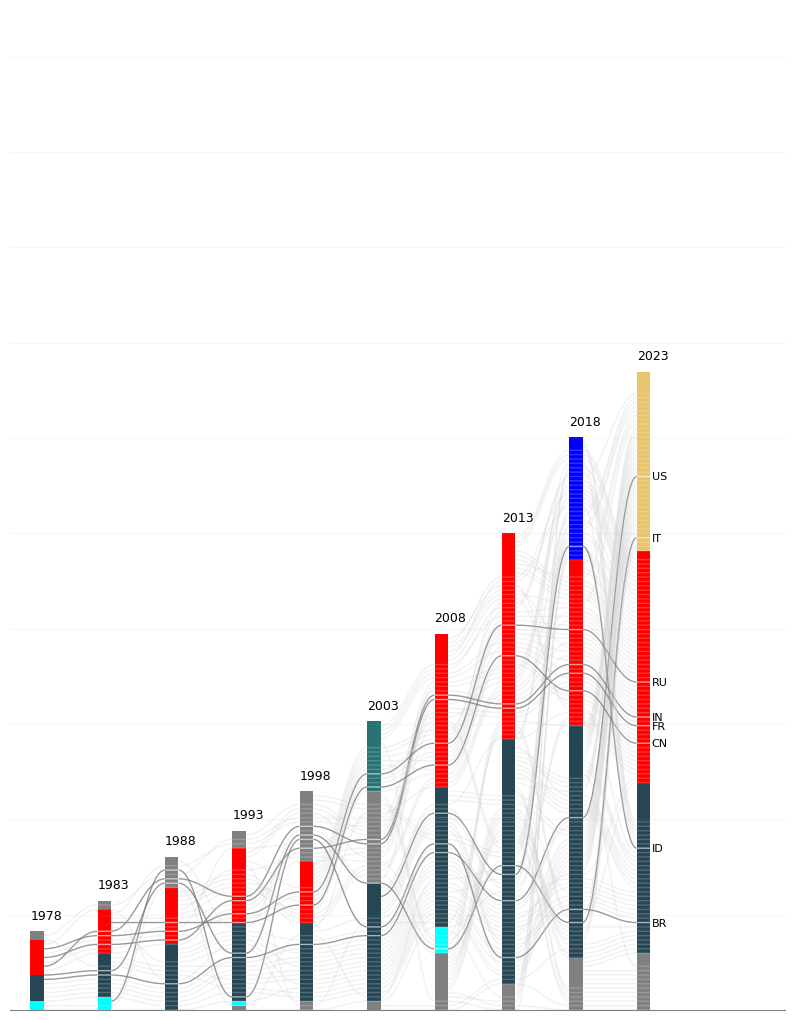

In [659]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches


fig, ax = plt.subplots(figsize=(10, 13))

to_print_list = ["US", "CN", "RU", "IT", "FR", "IN", "ID", "BR"]
printed_list = []
for i, (x, y, w, h) in enumerate(rectangles):
    rect = patches.Rectangle(
        (x, y), w, h,
        edgecolor=None,
        facecolor=color_array[rectangles.index((x, y, w, h))],
        # alpha=0.7
    )
    ax.add_patch(rect)

    
    
    if not isinstance(country_array[i], list):
        continue
    for (x0, y0, x1, y1, c) in country_array[i]:
        if c in to_print_list:
            draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="grey", alpha=0.8)
        else:
            draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="lightgrey", alpha=0.3)

    for (x0, y0, x1, y1, c) in country_cluster_array[i]:
        if c in to_print_list:
            draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.6)
            if c not in printed_list:
                ax.text(x1+0.02, y1, c, ha='left', va='center', fontdict={"size": 8, "family":"sans-serif"})
                printed_list.append(c)
        else:
            draw_flow(ax, x0, y0, x1, y1, curvature=0.4, color="white", alpha=0.2)


for year in year_list_10y:
    x_text = len(year_list_10y) - list(year_list_10y).index(year) - width
    y_text = df_tmp.query("year == @year").country_share.sum() + 0.01
    ax.text(x_text, y_text, str(year), ha='left', va='bottom', fontdict={"size": 9, "family":"sans-serif"})

ax.set_xlim(0.5, 12)
ax.set_ylim(0, 1 + 0.05)
# ax.set_ylim(-0.5, total_share + 0.1)

ax.set_xticks([])
ax.set_yticks(np.linspace(0, 1, 11), labels=[None]*11)
ax.tick_params(axis='y', color='none')
ax.yaxis.tick_right()
ax.yaxis.set_label_position("left")
# ax.set_yticks(np.linspace(0, 0.6, 7), labels=[f"{int(x*100)}%" for x in np.linspace(0, 0.6, 7)])
# ax.set_xticklabels(list(reversed(year_list_10y)))

# ax.spines['bottom'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['right'].set_color("grey")
ax.spines['bottom'].set_color("grey")
# ax.spines['left'].set_position(('data', 0.1))
# ax.spines['left'].set_position(('axes', 0))
# ax.margins(x=0.5)
# ax.set_title("Country cluster membership over time")
plt.grid(alpha=0.1)
# ax.text(2.5, -0.475, "Cluster domain under- and overrepresentation", ha='center', va='bottom')
# plt.subplots_adjust(left=-0.1)
# plt.show()
plt.savefig("fig.svg")

In [660]:
df_spec_list = []
for year_loop in year_list_10y:
    df_spec = get_spec_by_domain(year_loop).reset_index(names="cluster").assign(year=year_loop)
    df_spec_list.append(df_spec)
df_spec_years = pd.concat(df_spec_list, axis=0)

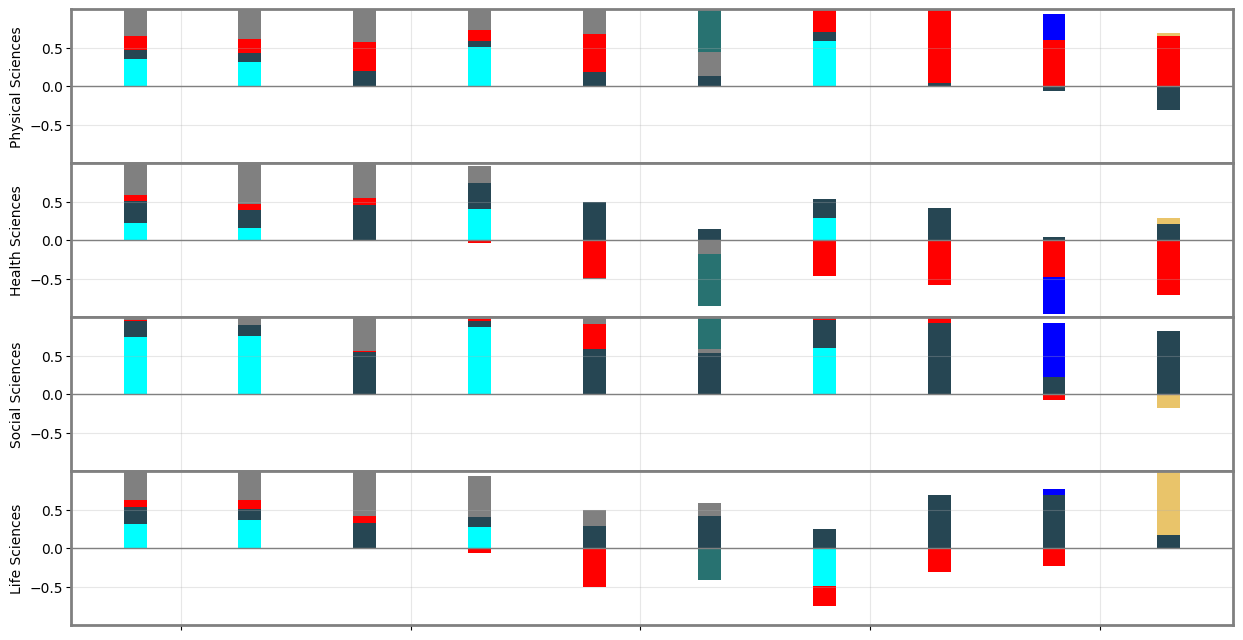

In [661]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(domain_list),
    ncols=1,
    figsize=(15, 2 * len(domain_list)),
    sharex=True
)

# If only one domain, make axes iterable
if len(domain_list) == 1:
    axes = [axes]

for ax, domain in zip(axes, domain_list):
    # Prepare data
    df_plot = df_spec_years.pivot(index="year", columns="cluster", values=domain)
    x = df_plot.index

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_plot))
    neg_sum = np.zeros(len(df_plot))

    # Plot stacked bars
    for cluster in df_plot.columns:
        y = df_plot[cluster].values

        y_pos = np.where(y > 0, y, 0)
        y_neg = np.where(y < 0, y, 0)

        color = color_dict_tmp.get(cluster, "grey")

        # Positive stack
        ax.bar(
            x, y_pos,
            bottom=pos_sum,
            color=color,
            width=1,
            # alpha=0.6
        )

        # Negative stack
        ax.bar(
            x, y_neg,
            bottom=neg_sum,
            color=color,
            width=1,
            # alpha=0.6
        )

        # Update stacks
        pos_sum += y_pos
        neg_sum += y_neg

    # Baseline
    ax.axhline(0, color="grey", linewidth=1)
    # ax.axhline(1, color="grey", linewidth=4)

    # Limits and labels
    ax.set_ylim(-1, 1)
    ax.set_ylabel(domain)

    # Grid
    ax.set_yticks([-0.5, 0, 0.5])
    ax.tick_params(axis='y', pad=2)
    ax.grid(alpha=0.3)

# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes):
    # ax.spines['right'].set_visible(False)
    ax.spines["right"].set_color("grey")
    ax.spines["right"].set_linewidth(2)
    ax.spines["left"].set_color("grey")
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_color("grey")
    ax.spines["top"].set_linewidth(2)
    ax.spines["bottom"].set_color("grey")
    ax.spines["bottom"].set_linewidth(2)
    # Top spine only for first plot
    # if i == 0:
    #     ax.spines['top'].set_visible(True)
    # else:
    #     ax.spines['top'].set_visible(False)

    # Bottom spine only for last plot
    # if i == len(axes) - 1:
    #     ax.spines['bottom'].set_visible(True)
    # else:
    #     ax.spines['bottom'].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.set_xticklabels([])

# axes[-1].set_xticks(x)
# axes[-1].set_xticklabels(x)

plt.show()

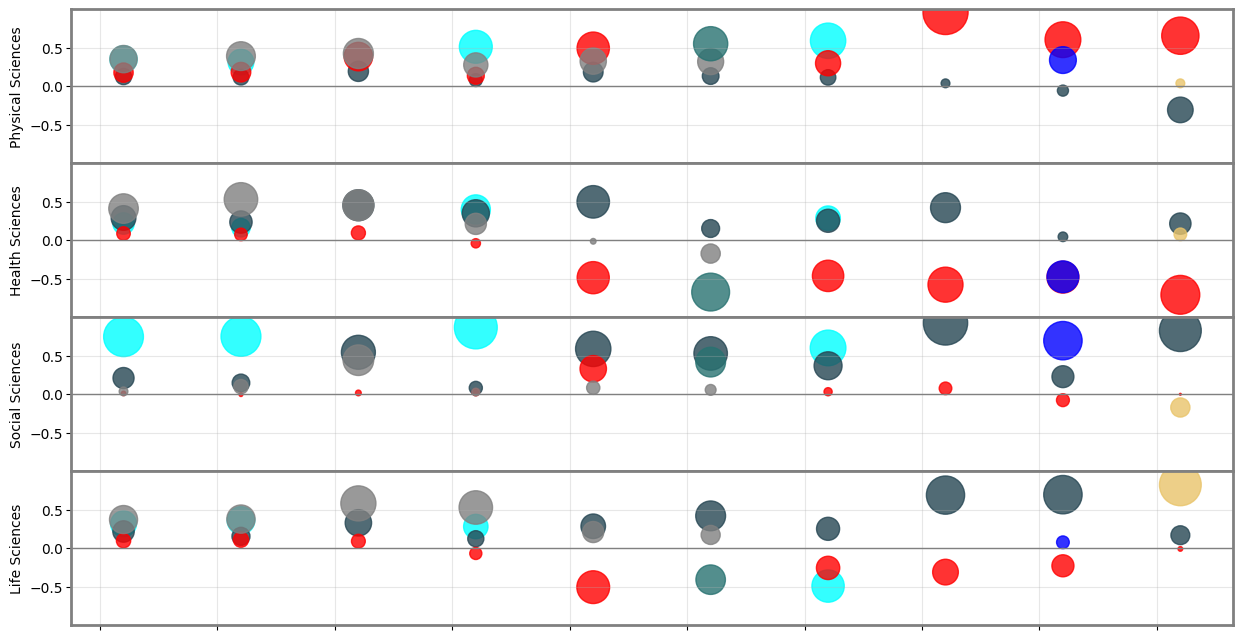

In [662]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(domain_list),
    ncols=1,
    figsize=(15, 2 * len(domain_list)),
    sharex=True
)

# If only one domain, make axes iterable
if len(domain_list) == 1:
    axes = [axes]

for ax, domain in zip(axes, domain_list):
    # Prepare data
    df_plot = df_spec_years.pivot(index="year", columns="cluster", values=domain)
    x = df_plot.index

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_plot))
    neg_sum = np.zeros(len(df_plot))

    offset_size = 0 / len(df_plot.columns)
    cluster_offset = 1
    # Plot stacked bars
    for cluster in df_plot.columns:
        y = df_plot[cluster].values
        x_offset = x + cluster_offset
        ax.scatter(x_offset, y, s=1100*abs(y), label=f"Cluster {cluster}", color=color_dict_tmp.get(cluster, "grey"), linewidth=1, alpha=0.8)
        cluster_offset += offset_size

    # Baseline
    ax.axhline(0, color="grey", linewidth=1)
    # ax.axhline(1, color="grey", linewidth=4)

    # Limits and labels
    ax.set_ylim(-1, 1)
    ax.set_ylabel(domain)

    # Grid
    ax.set_yticks([-0.5, 0, 0.5])
    ax.set_xticks(df_plot.index)
    ax.tick_params(axis='y', pad=2)
    ax.grid(alpha=0.3)
    # ax.axvspan(1993, 2003, color='lightgrey', alpha=0.2, zorder=0)
    # ax.axvspan(2013, 2023, color='lightgrey', alpha=0.2, zorder=0)
    # ax.axhspan(-1, 0, color='lightgrey', alpha=0.2, zorder=0)

# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes):
    # ax.spines['right'].set_visible(False)
    ax.spines["right"].set_color("grey")
    ax.spines["right"].set_linewidth(2)
    ax.spines["left"].set_color("grey")
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_color("grey")
    ax.spines["top"].set_linewidth(2)
    ax.spines["bottom"].set_color("grey")
    ax.spines["bottom"].set_linewidth(2)
    # Top spine only for first plot
    # if i == 0:
    #     ax.spines['top'].set_visible(True)
    # else:
    #     ax.spines['top'].set_visible(False)

    # Bottom spine only for last plot
    # if i == len(axes) - 1:
    #     ax.spines['bottom'].set_visible(True)
    # else:
    #     ax.spines['bottom'].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.set_xticklabels([])

# axes[-1].set_xticks(x)
# axes[-1].set_xticklabels(x)

plt.show()

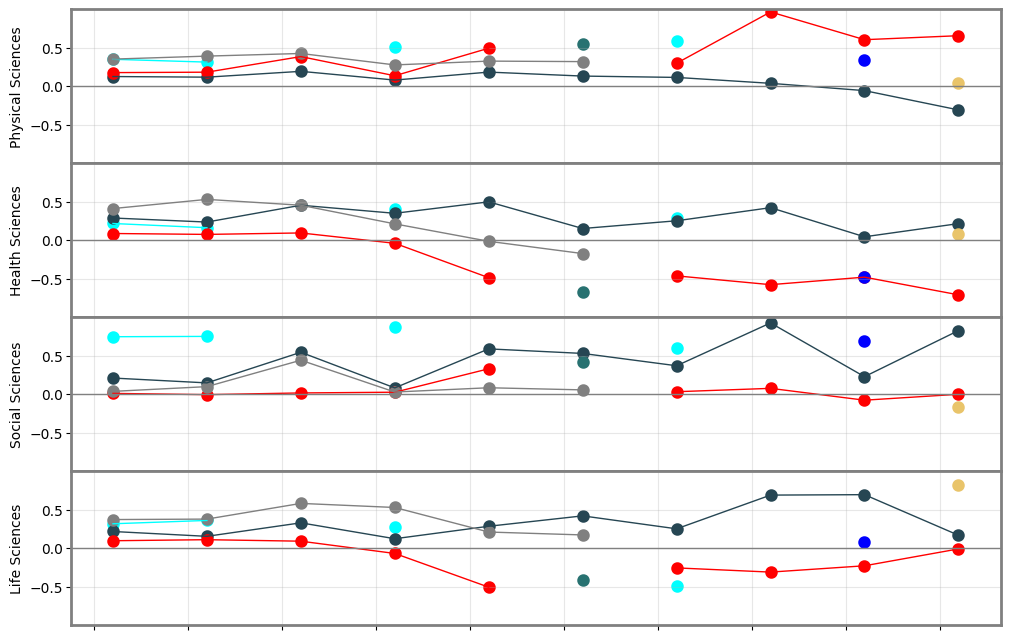

In [663]:
import numpy as np
import matplotlib.pyplot as plt

# Create figure with one column and multiple rows
fig, axes = plt.subplots(
    nrows=len(domain_list),
    ncols=1,
    figsize=(12, 2 * len(domain_list)),
    sharex=True
)

# If only one domain, make axes iterable
if len(domain_list) == 1:
    axes = [axes]

for ax, domain in zip(axes, domain_list):
    # Prepare data
    df_plot = df_spec_years.pivot(index="year", columns="cluster", values=domain)
    x = df_plot.index

    # Initialize stacking arrays
    pos_sum = np.zeros(len(df_plot))
    neg_sum = np.zeros(len(df_plot))

    offset_size = 0 / len(df_plot.columns)
    cluster_offset = 1
    # Plot stacked bars
    for cluster in df_plot.columns:
        y = df_plot[cluster].values
        x_offset = x + cluster_offset
        ax.scatter(x_offset, y, label=f"Cluster {cluster}", color=color_dict_tmp.get(cluster, "grey"), linewidth=3)
        ax.plot(x_offset, y, label=f"Cluster {cluster}", color=color_dict_tmp.get(cluster, "grey"), linewidth=1)
        cluster_offset += offset_size

    # Baseline
    ax.axhline(0, color="grey", linewidth=1)
    # ax.axhline(1, color="grey", linewidth=4)

    # Limits and labels
    ax.set_ylim(-1, 1)
    ax.set_ylabel(domain)

    # Grid
    ax.set_yticks([-0.5, 0, 0.5])
    ax.set_xticks(df_plot.index)
    ax.tick_params(axis='y', pad=2)
    ax.grid(alpha=0.3)
    # ax.axvspan(1993, 2003, color='lightgrey', alpha=0.2, zorder=0)
    # ax.axvspan(2013, 2023, color='lightgrey', alpha=0.2, zorder=0)
    # ax.axhspan(-1, 0, color='lightgrey', alpha=0.2, zorder=0)

# 🔗 Remove vertical spacing between subplots
plt.subplots_adjust(hspace=0)

# 🧱 Spine control (make them visually continuous)
for i, ax in enumerate(axes):
    # ax.spines['right'].set_visible(False)
    ax.spines["right"].set_color("grey")
    ax.spines["right"].set_linewidth(2)
    ax.spines["left"].set_color("grey")
    ax.spines["left"].set_linewidth(2)
    ax.spines["top"].set_color("grey")
    ax.spines["top"].set_linewidth(2)
    ax.spines["bottom"].set_color("grey")
    ax.spines["bottom"].set_linewidth(2)
    # Top spine only for first plot
    # if i == 0:
    #     ax.spines['top'].set_visible(True)
    # else:
    #     ax.spines['top'].set_visible(False)

    # Bottom spine only for last plot
    # if i == len(axes) - 1:
    #     ax.spines['bottom'].set_visible(True)
    # else:
    #     ax.spines['bottom'].set_visible(False)

# 📍 X-axis only on bottom plot
for ax in axes[:-1]:
    ax.set_xticklabels([])

# axes[-1].set_xticks(x)
# axes[-1].set_xticklabels(x)

plt.show()

In [664]:
df_spec = get_spec_by_domain(2023)

In [616]:
df_spec

,Health Sciences,Life Sciences,Physical Sciences,Social Sciences
cluster,,,,
5.0,0.383948,0.822117,0.254837,-0.305049
10.0,-0.137222,-0.052879,-0.069237,0.604922
12.0,-0.478830,0.125004,0.675926,0.090028


In [617]:
df_dist_country_global_list = []
for year_loop in years_list:
    df1 = df_prob_yearly.xs(year_loop, level=1)
    df2 = df_baricenter_global_yearly.loc[year_loop].to_frame("Global").T

    df_dist_country_global_list.append(uf.get_w1_distances_matrix(df1, df2)
                                            .reset_index(names="country")
                                            .melt(id_vars="country", var_name="global")
                                            .assign(year=year_loop)
                                            )

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/util

In [489]:
df_dist_country_global = pd.concat(df_dist_country_global_list)

In [440]:
(
    df_cs_yearly.sum(axis=1).to_frame("total")
    .merge(df_map_analysis[["country", "year"]], left_index=True, right_on=["country", "year"], how="right")
    .query("year == 2023")
    .assign(log_total=lambda df: np.log(df.total))
)

,total,country,year,log_total
3128,35565.0,AE,2023,10.479117
3129,825.0,AF,2023,6.715383
3130,1380.0,AL,2023,7.229839
3131,2092.0,AM,2023,7.645876
3132,34871.0,AR,2023,10.459411
...,...,...,...,...
3269,36001.0,VN,2023,10.491302
3270,4173.0,YE,2023,8.336390
3271,58877.0,ZA,2023,10.983206
3272,2980.0,ZM,2023,7.999679


In [441]:
df_log_total = (
    df_cs_yearly.sum(axis=1).to_frame("total")
    .merge(df_map_analysis[["country", "year"]], left_index=True, right_on=["country", "year"], how="right")
    .query("year == 2023")
    .assign(log_total=lambda df: np.log(df.total))
)

df_plot = (
    df_dist_country_global
    .merge(df_map_analysis[["country", "year"]], left_on=["country", "year"], right_on=["country", "year"], how="right")
    .groupby(["country"], as_index=False)
    .value.median()
    .merge(df_map_analysis.query("year == 2023")[["country", "cluster"]], left_on=["country"], right_on=["country"], how="left")
    .rename(columns={"value": "mean_dist"})
    .merge(uf.df_country[["alpha-2", "name", "sub-region", "region"]], left_on="country", right_on="alpha-2", how="left")
    .merge(df_log_total[["country", "log_total", "total"]], left_on="alpha-2", right_on="country", how="left")
    .sort_values(["mean_dist", "log_total",])
    .head(20)
)
df_plot
# df_plot.sort_values("log_total")

,country_x,mean_dist,cluster,alpha-2,name,sub-region,region,country_y,log_total,total
34,DE,0.020184,3.0,DE,Germany,Western Europe,Europe,DE,13.008408,446149.0
45,FR,0.028450,3.0,FR,France,Western Europe,Europe,FR,12.546722,281172.0
41,ES,0.039049,3.0,ES,Spain,Southern Europe,Europe,ES,12.424670,248866.0
64,IT,0.046532,8.0,IT,Italy,Southern Europe,Europe,IT,12.539089,279034.0
55,HR,0.052886,8.0,HR,Croatia,Southern Europe,Europe,HR,9.636261,15310.0
130,TR,0.055037,3.0,TR,Türkiye,Western Asia,Asia,TR,11.242887,76335.0
5,AT,0.056096,8.0,AT,Austria,Western Europe,Europe,AT,11.335018,83702.0
109,PT,0.057673,3.0,PT,Portugal,Southern Europe,Europe,PT,11.269822,78419.0
92,MX,0.058697,3.0,MX,Mexico,Latin America and the Caribbean,Americas,MX,11.027394,61537.0
63,IS,0.060895,8.0,IS,Iceland,Northern Europe,Europe,IS,8.651199,5717.0


TypeError: object of type 'float' has no len()

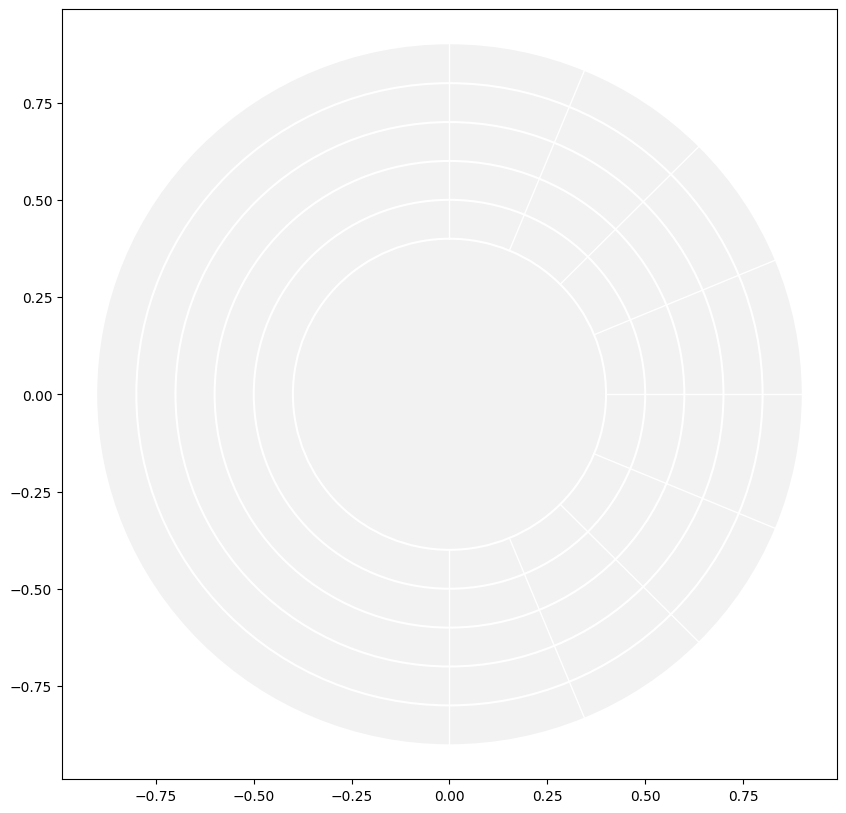

In [442]:
fig, ax = plt.subplots(figsize=(10, 10))

n_angle = 9
angle_grid = np.linspace(-90, 90, n_angle)

angle_min = 8
angle_max = 15.2
angle_grid_labels = np.linspace(angle_min, angle_max, n_angle)

log_total = df_plot.log_total.values
log_total_angle = (log_total - angle_min) / (angle_max - angle_min) * 180 - 90

radius_grid = np.arange(4, 9) / 10
radius_grid_labels = [f"{int(r/10)}" for r in radius_grid]
dist = df_plot.mean_dist.values
dist_radius = dist * 10

x_array = dist_radius * np.cos(np.radians(log_total_angle))
y_array = dist_radius * np.sin(np.radians(log_total_angle))
color_array = df_plot.cluster.map(color_dict_tmp).values

log_total_radius_start = 0.4
x_array_log_total_start = log_total_radius_start * np.cos(np.radians(angle_grid))
y_array_log_total_start = log_total_radius_start * np.sin(np.radians(angle_grid))
log_total_radius = 0.9
x_array_log_total = log_total_radius * np.cos(np.radians(angle_grid))
y_array_log_total = log_total_radius * np.sin(np.radians(angle_grid))
# radius_grid

x = 0
y = 0


circle = patches.Circle((x, y), radius=0.9, edgecolor='none', facecolor="#F2F2F2", linestyle='--', zorder=0)
ax.add_patch(circle)

for raduis_loop in radius_grid:
    # print(raduis_loop)
    circle = patches.Circle((x, y), radius=raduis_loop, edgecolor='white', facecolor='none', linewidth=1.5, zorder=1)
    ax.add_patch(circle)

for x1, y1, x2, y2 in zip(x_array_log_total_start, y_array_log_total_start, x_array_log_total, y_array_log_total):
    ax.plot([x1, x2], [y1, y2], color="white", linewidth=1, zorder=1)



for x, y, c, name, o in zip(x_array, y_array, color_array, df_plot["country_x"], np.arange(2, x_array.shape[0]+2)):
    ax.scatter(x, y, s=500, color=c, alpha=0.9, zorder=o)
    ax.text(x, y, name, fontsize=12, color="white", ha='center', va='center', zorder=o)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

ax.set_xticks([])
ax.set_yticks([])
# ax.spines['left'].set_bounds(0, 1 + 0.05)
# ax.spines['left'].set_color("grey")
# ax.spines['bottom'].set_color("grey")
# ax.spines['left'].set_position(('data', 0.1))
ax.set_ylim(-1, 1)
ax.set_xlim(0, 2)

In [443]:
def get_prob_by_domain(year):
    n_all = df_map_analysis.query("year == @year").groupby("cluster", as_index=False).country.nunique().country.sum()

    df_prob_domain = (
        df_prob_yearly
        .xs(year, level=1)
        .T
        .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
                left_index=True, right_on="subfield_str", how="left")
        .drop(columns=["subfield_id", "subfield_str"])
        .groupby("domain_name").sum()
        .T
    )
    return df_prob_domain
    std = (
        df_prob_domain
        .merge(df_map_analysis.query("year == @year")[["country"]], left_index=True, right_on="country", how="right")
        .set_index("country")
        .std()
    )

    n_countries_cluster = df_map_analysis.query("(year == @year)  and (cluster != 0)").groupby("cluster").country.nunique().to_frame("n_countries")

    div_test = 1 / np.sqrt(
            pd.DataFrame((std ** 2).to_frame("std_global").T.values / n_countries_cluster.values, index=n_countries_cluster.index, columns=std.index)
            .mul((n_all - n_countries_cluster.values) / (n_all - 1), axis=0)
    ).dropna(how="all")

    res = ((
        df_prob_domain
        .merge(df_map_analysis.query("(year == @year) and (cluster != 0)")[["country", "cluster"]], left_index=True, right_on="country", how="left")
        .drop(columns=["country"])
        .groupby("cluster", as_index=False)
        .mean()
        .set_index("cluster")
    ) - (
        df_prob_domain
        .merge(df_map_analysis.query("year == @year")[["country"]], left_index=True, right_on="country", how="left")
        .drop(columns=["country"])
        .mean()
    )) / div_test.values
    return res / res.abs().sum()

In [444]:
year = 2013

df_cluster_domain = (
    (
        df_cs_yearly
        .xs(year, level=1)
        .T
        .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
                left_index=True, right_on="subfield_str", how="left")
        .drop(columns=["subfield_id", "subfield_str"])
        .groupby("domain_name").sum()
        .T
    )
    .merge(df_map_analysis.query("year == @year"), left_index=True, right_on="country", how="right")
    .drop(columns=["year", "country"])
    .groupby("cluster")
    .sum()
)

In [445]:
df_cluster_domain.div(df_cluster_domain.sum())

,Health Sciences,Life Sciences,Physical Sciences,Social Sciences
cluster,,,,
0.0,0.001586,0.001318,0.003390,0.006894
2.0,0.678237,0.611063,0.505538,0.664306
3.0,0.320178,0.387619,0.491072,0.328800


In [446]:
df_hh_score_list = []
df_cluster_domain_list = []
for year_loop in year_list:
    df_cluster_domain = (
        (
            df_cs_yearly
            .xs(year, level=1)
            .T
            .merge(uf.df_topics[["subfield_id", "domain_name"]].drop_duplicates().assign(subfield_str=lambda df: df.subfield_id.astype(str)),
                    left_index=True, right_on="subfield_str", how="left")
            .drop(columns=["subfield_id", "subfield_str"])
            .groupby("domain_name").sum()
            .T
        )
        .merge(df_map_analysis.query("year == @year_loop"), left_index=True, right_on="country", how="right")
        .drop(columns=["year", "country"])
        .groupby("cluster")
        .sum()
    )
    df_cluster_domain_list.append(df_cluster_domain.div(df_cluster_domain.sum()).assign(year=year_loop))
    df_hh_score_list.append((df_cluster_domain.div(df_cluster_domain.sum())**2).sum().to_frame("hhi_score").reset_index(names="domain").assign(year=year_loop))

In [447]:
df_hh_score = pd.concat(df_hh_score_list)
df_cluster_domain_yearly = pd.concat(df_cluster_domain_list)

In [448]:
px.line(df_hh_score, x="year", y="hhi_score", color="domain")

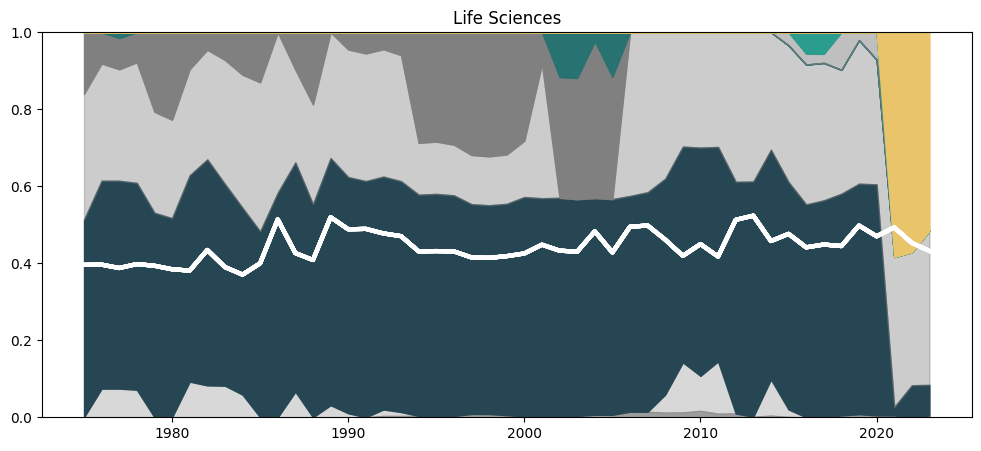

In [449]:
plt.subplots(figsize=(12, 5))
domain = domain_list[3]

df_tmp = df_cluster_domain_yearly[[domain, "year"]]

alpha_grey = 0.3
cluster_test_list = list(set(df_tmp.index))

y2 = np.zeros(len(year_list))
for cluster_loop in cluster_test_list:
    
    if not (cluster_loop in color_dict_tmp.keys()):
        color="grey"
        alpha = alpha_grey
        alpha_grey += 0.1
    else:
        color = color_dict_tmp[cluster_loop]
        alpha=1
    x = year_list
    y = df_tmp.reset_index(names="cluster").query("cluster == @cluster_loop").set_index("year").reindex(year_list).fillna(0)[domain]
    y1 = y2
    y2 = y2+y

    
    # print(cluster_loop, color, alpha)

#     y1 = y2
#     y2 = y2 + df_cluster_domain_yearly.query("domain == ")
#     # plt.plot(year_list, y2)
#     # plt.plot(year_list, y3)
    plt.plot(year_list, df_hh_score.query("domain == @domain").hhi_score.values, color="white", linewidth=3)
    plt.fill_between(
        year_list,
        y1,
        y2,
        color=color,
        alpha=alpha,
        label=cluster_loop
    )
# plt.legend()
plt.ylim(0, 1)
_ = plt.title(domain)

In [450]:
df_dist_yearly

,,AE,AF,AG,AL,AM,AR,AT,AU,AZ,BA,...,AD,GQ,CV,ER,KN,SJ,AW,TC,TL,EH
country,year,,,,,,,,,,,,,,,,,,,,,
AE,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AF,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AG,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AL,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AM,1970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WS,2023,0.472853,0.204601,0.467795,0.317231,0.457480,0.341920,0.364213,0.362682,0.385699,0.283687,...,0.354373,0.405697,0.416966,0.271657,0.299343,0.864697,0.338953,0.209209,0.190383,NaN
YE,2023,0.082296,0.252264,0.559474,0.132678,0.078608,0.131636,0.095497,0.090066,0.118205,0.163461,...,0.232025,0.520629,0.179812,0.229373,0.531470,0.473670,0.455377,0.490215,0.355246,NaN
ZA,2023,0.156827,0.145439,0.514092,0.057775,0.143511,0.093204,0.064016,0.042884,0.129254,0.076014,...,0.142294,0.444952,0.216299,0.142766,0.454550,0.559385,0.390072,0.408124,0.272904,NaN


In [451]:
df_map_analysis.query("(year == 2023) and (country in @c_list)")

,year,country,cluster
3146,2023,BR,2.0
3152,2023,CH,8.0
3156,2023,CN,3.0
3173,2023,FR,3.0
3185,2023,ID,2.0
3188,2023,IN,3.0
3243,2023,RU,3.0
3264,2023,US,8.0


In [452]:
c1 = "RU"
c_list = ["US", "CN", "IN", "ID", "RU", "FR", "CH", "BR"]
px.line(df_dist_yearly.xs(c1)[c_list], x=df_dist_yearly.xs(c1)[c_list].index, y=c_list)

In [453]:
df_profile_yearly

1102      1103      1105      1109      1110      1310  \
cluster year                                                               
0.0     1992  0.095175  0.061930  0.061929  0.061929  0.103030  0.062493   
        1993  0.079954  0.066628  0.066628  0.066628  0.079954  0.058166   
        1994  0.062472  0.051271  0.051103  0.051103  0.062472       NaN   
        1995  0.059482  0.044265  0.044265  0.044099  0.063755       NaN   
        1996  0.043074  0.041360  0.041361  0.041201  0.067381       NaN   
...                ...       ...       ...       ...       ...       ...   
7.0     2016  0.004317  0.002583  0.018771  0.004702  0.062805  0.002729   
        2017  0.002582  0.001441  0.021296  0.002579  0.104566  0.002344   
8.0     2021  0.004366  0.004166  0.011567  0.006208  0.026479  0.002386   
        2022  0.002718  0.002712  0.007061  0.003995  0.019865  0.002125   
        2023  0.002950  0.003625  0.010466  0.004646  0.047303  0.001980   

                  1311      1312      1605      1607  ...      2922      3309  \
cluster year                                          ...                       
0.0     1992  0.106356  0.103162  0.033772  0.032228  ...       NaN       NaN   
        1993  0.068439  0.068439  0.036738  0.035180  ...       NaN       NaN   
        1994  0.071647  0.085534  0.025777  0.023936  ...       NaN       NaN   
        1995  0.062060  0.097435  0.031073  0.026639  ...       NaN       NaN   
        1996  0.053523  0.098013  0.027076  0.021627  ...       NaN       NaN   
...                ...       ...       ...       ...  ...       ...       ...   
7.0     2016  0.013177  0.017358  0.001017  0.000760  ...       NaN       NaN   
        2017  0.011538  0.018132  0.000431  0.000345  ...       NaN       NaN   
8.0     2021  0.015499  0.027240  0.003984  0.002494  ...  0.001035  0.001826   
        2022  0.011129  0.032784  0.004905  0.002324  ...  0.001043  0.001741   
        2023  0.012386  0.029317  0.004006  0.002266  ...  0.000956  0.001622   

                  3500      2911  3608      2104      2718      1200  \
cluster year                                                           
0.0     1992       NaN       NaN   NaN       NaN       NaN       NaN   
        1993       NaN       NaN   NaN       NaN       NaN       NaN   
        1994       NaN       NaN   NaN       NaN       NaN       NaN   
        1995       NaN       NaN   NaN       NaN       NaN       NaN   
        1996       NaN       NaN   NaN       NaN       NaN       NaN   
...                ...       ...   ...       ...       ...       ...   
7.0     2016  0.000156       NaN   NaN       NaN       NaN       NaN   
        2017  0.000103       NaN   NaN       NaN       NaN       NaN   
8.0     2021  0.000502  0.001035   NaN       NaN  0.002446  0.000244   
        2022  0.000664  0.001043   NaN  0.001417  0.001875  0.000268   
        2023  0.000458  0.000954   NaN  0.001298  0.001800  0.000178   

                  3319  1410  
cluster year                  
0.0     1992       NaN   NaN  
        1993       NaN   NaN  
        1994       NaN   NaN  
        1995       NaN   NaN  
        1996       NaN   NaN  
...                ...   ...  
7.0     2016       NaN   NaN  
        2017  0.002283   NaN  
8.0     2021  0.001826   NaN  
        2022  0.001741   NaN  
        2023  0.001622   NaN  

[189 rows x 251 columns]

In [454]:
df_dist_clusters_list = []
for year_loop in year_list:
    df1 = df_profile_yearly.xs(year_loop, level=1)
    df2 = df_profile_yearly.xs(year_loop, level=1)

    df_dist_clusters_list.append(uf.get_w1_distances_matrix(df1, df2).reset_index(names="cluster_from").melt(id_vars="cluster_from", var_name="cluster_to", value_name="dist").assign(year=year_loop))
df_dist_clusters_yearly = pd.concat(df_dist_clusters_list)

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/util

In [455]:
df_dist_clusters_list = []
for year_loop in year_list:
    df1 = df_profile_yearly.xs(year_loop, level=1)
    df2 = df_baricenter_global_yearly.loc[year_loop].to_frame("global").T

    df_dist_clusters_list.append(uf.get_w1_distances_matrix(df1, df2).reset_index(names="cluster_from").melt(id_vars="cluster_from", var_name="cluster_to", value_name="dist").assign(year=year_loop))
df_dist_clusters_global_yearly = pd.concat(df_dist_clusters_list)

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1245: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

divide by zero encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

overflow encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/utility_functions.py:1372: RuntimeWarning:

invalid value encountered in matmul

/Users/irinavorobeva/Documents/Sociology/Geography Topics/geoTopics/irina/util

In [456]:
df_dist_clusters_yearly

,cluster_from,cluster_to,dist,year
0,2.0,2.0,0.000000,1975
1,3.0,2.0,0.247434,1975
2,4.0,2.0,0.148210,1975
3,2.0,3.0,0.247434,1975
4,3.0,3.0,0.000000,1975
...,...,...,...,...
11,8.0,3.0,0.139929,2023
12,0.0,8.0,0.280312,2023
13,2.0,8.0,0.108305,2023
14,3.0,8.0,0.139929,2023


In [457]:
df_dist_clusters_global_yearly

,cluster_from,cluster_to,dist,year
0,2.0,global,0.186438,1975
1,3.0,global,0.065873,1975
2,4.0,global,0.064611,1975
0,1.0,global,0.074866,1976
1,2.0,global,0.163013,1976
...,...,...,...,...
3,8.0,global,0.015299,2022
0,0.0,global,0.326094,2023
1,2.0,global,0.102794,2023
2,3.0,global,0.109787,2023


In [458]:
# cluster_from = "5.0"
null_cluster = "0.0"
px.line(df_dist_clusters_global_yearly.query("(cluster_from != @null_cluster)"), x="year", y="dist", color="cluster_from")

In [459]:
cluster_from = "5.0"
null_cluster = "0.0"
px.line(df_dist_clusters_yearly.query("(cluster_from == @cluster_from) and (cluster_to != @null_cluster)"), x="year", y="dist", color="cluster_to")

In [460]:
df_dist_country_cluster.query("(country == @c1) and (year == 2023)")

,country,value,year,cluster_dist,cluster_map,in_cluster
12750,RU,0.470052,2023,0.0,3.0,0
12751,RU,0.288806,2023,2.0,3.0,0
12752,RU,0.081847,2023,3.0,3.0,1
12753,RU,0.209059,2023,8.0,3.0,0


In [461]:
all_c = df_map_analysis.query("year == 2023").sort_values("cluster").country.to_list()
df_plot = df_dist_yearly.xs(2023, level=1).loc[all_c, all_c]
uf.plotly_heatmap(df_plot, x_labels=df_plot.index, y_labels=df_plot.columns, x_type="country", y_type="country")